<a href="https://colab.research.google.com/github/opaiot/ia-otimizacao-iot-industrias-negocios-public/blob/feature%2Fsync-colab/M1/colab/M1_Aulas_10_15_Aplica%C3%A7%C3%A3o_Pr%C3%A1tica_03.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

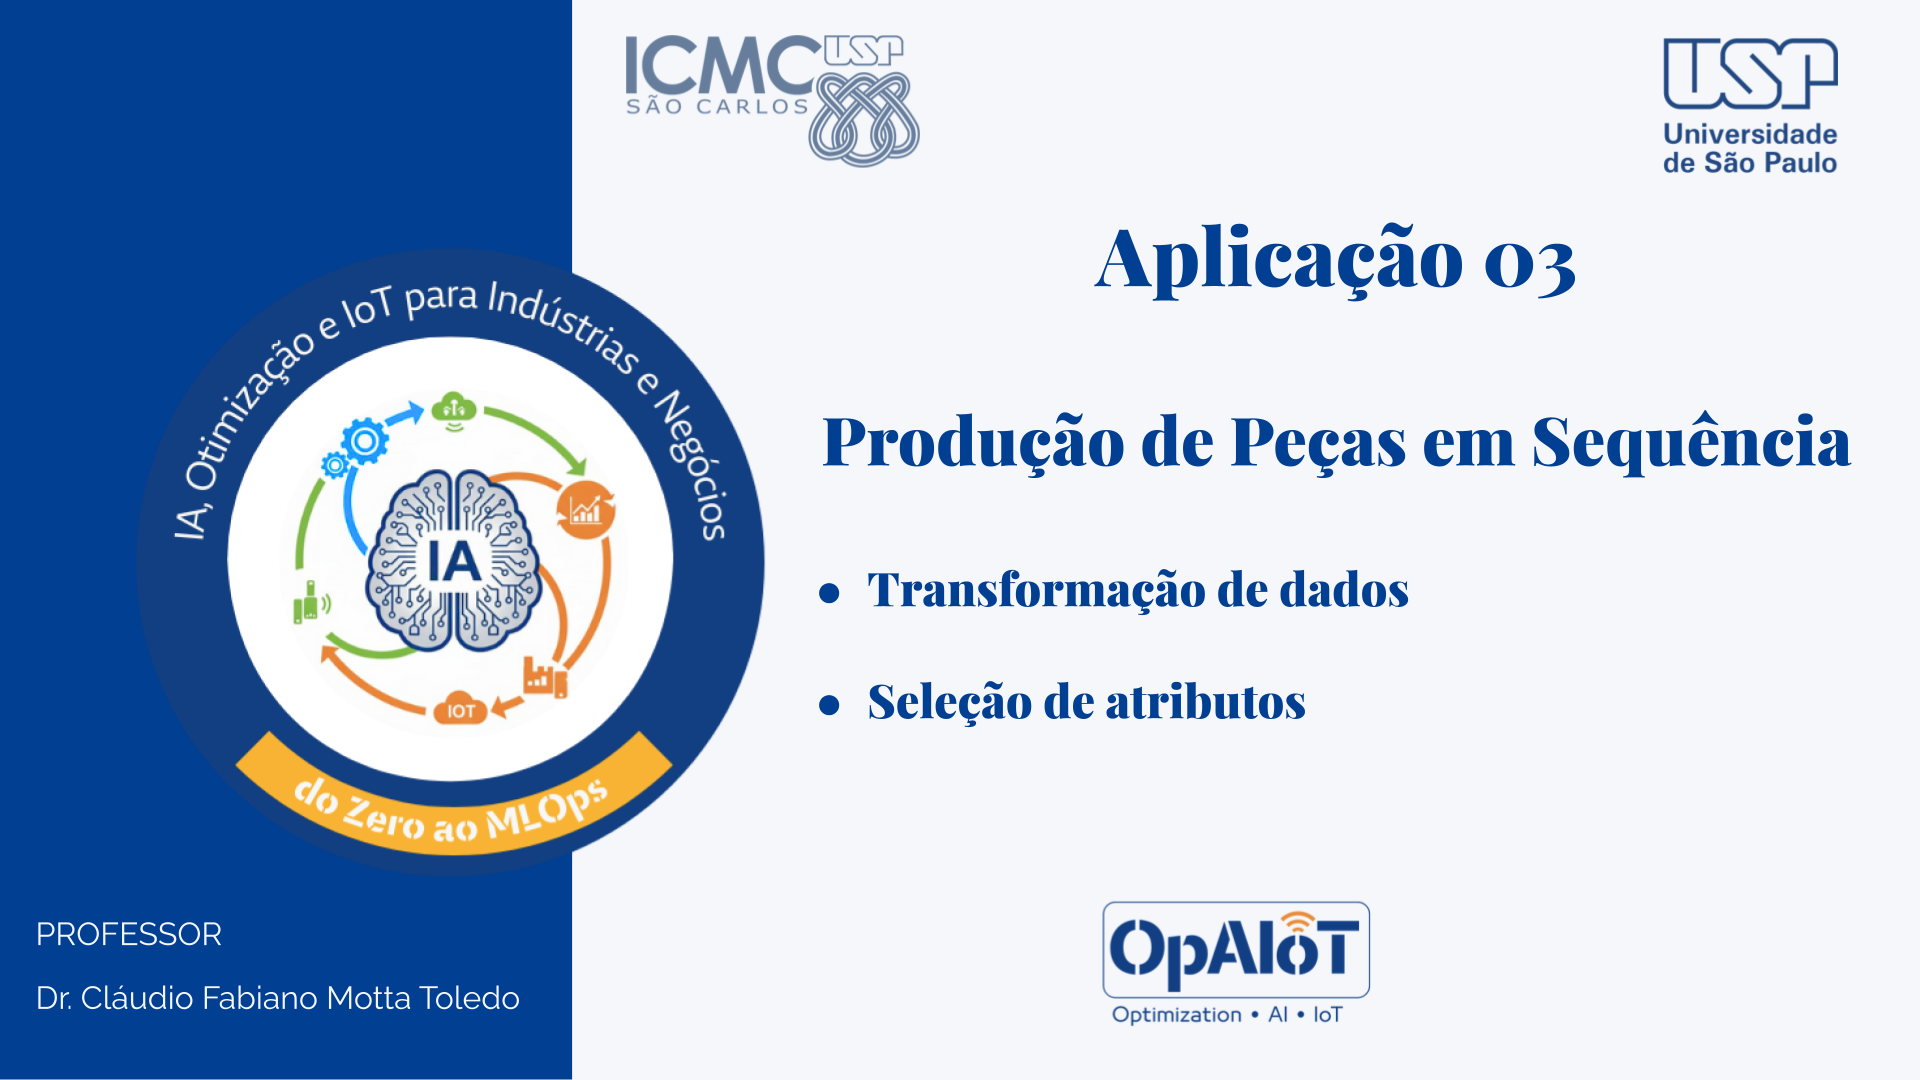

# Aula Prática 03 — Transformação de dados e seleção de atributos

Nesta prática, vamos dar continuidade ao problema industrial usado na Aula Prática 02.

Na aula anterior, o foco foi **tratamento e limpeza de dados**: valores ausentes, inconsistências, redundâncias, ruídos e outliers.

Agora, vamos trabalhar a etapa seguinte do pipeline de aprendizado de máquina:

> transformar os dados para que possam ser usados por modelos e selecionar atributos relevantes.

A aula está organizada em quatro blocos:

1. **Encoding de variáveis categóricas**
   - One-Hot Encoding;
   - Ordinal Encoding;
   - Frequency Encoding.

2. **Transformação numérico-simbólica**
   - intervalos de mesma largura;
   - intervalos de mesma frequência;
   - agrupamento com k-means.

3. **Transformação numérico-numérica**
   - padronização;
   - normalização Min-Max;
   - escalonamento robusto.

4. **Seleção de atributos**
   - método filter;
   - método wrapper com RFE;
   - método embedded.

O notebook foi construído para ser didático e progressivo. A ideia é primeiro entender cada transformação isoladamente e depois conectar essas transformações com a preparação dos dados para modelos de aprendizado de máquina.

## 1. Contexto do problema industrial

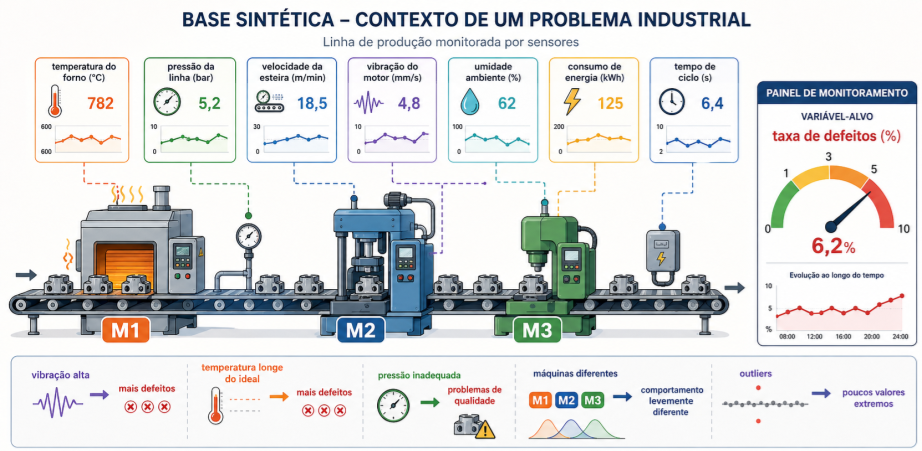
O objetivo é apoiar a equipe de engenharia a responder perguntas como:

- Quais variáveis estão mais associadas à taxa de defeitos?
- Como transformar variáveis categóricas em números?
- Como transformar variáveis numéricas para modelos sensíveis à escala?
- Como selecionar atributos mais relevantes para modelagem?
- Como preparar a mesma base para problemas de regressão e classificação?

Nesta prática, a base sintética será expandida para conter:

| Tipo de atributo | Exemplos na base |
|---|---|
| Categóricos nominais | `turno`, `maquina`, `tipo_produto`, `linha_producao` |
| Categóricos ordinais | `nivel_manutencao`, `nivel_desgaste`, `criticidade_operacao` |
| Alta cardinalidade | `fornecedor_lote`, `codigo_produto`, `codigo_operador` |
| Numéricos em escalas diferentes | temperatura, pressão, energia, tempo de ciclo |
| Redundantes | temperatura em Celsius e Fahrenheit, pressão backup |
| Irrelevantes | sensores aleatórios sem relação com o problema |
| Alvo de regressão | `taxa_defeitos_pct` |
| Alvo de classificação | `processo_critico` |

## 2. Bibliotecas usadas

Nesta célula, importamos as bibliotecas necessárias.

Principais recursos:

- `numpy`: geração de dados sintéticos e operações numéricas.
- `pandas`: manipulação de tabelas.
- `matplotlib` e `seaborn`: visualização de dados.
- `sklearn.preprocessing`: transformações de dados.
- `sklearn.feature_selection`: seleção de atributos.
- `sklearn.linear_model`: modelos usados em seleção wrapper e embedded.
- `sklearn.ensemble`: modelo baseado em árvores para importância de atributos.

A biblioteca `scikit-learn` será usada de forma guiada, pois muitos alunos ainda estão iniciando seu uso.

In [ ]:
# ------------------------------------------------------------
# 1) Importação das bibliotecas
# ------------------------------------------------------------

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

from sklearn.preprocessing import (
    StandardScaler,
    MinMaxScaler,
    RobustScaler,
    KBinsDiscretizer
)

from sklearn.feature_selection import SelectKBest, f_regression, f_classif, RFE
from sklearn.linear_model import LinearRegression, LogisticRegression, LassoCV
from sklearn.ensemble import RandomForestRegressor

# Configurações visuais e de exibição
pd.set_option("display.max_columns", 80)
pd.set_option("display.precision", 3)

sns.set_theme(style="whitegrid")

print("Bibliotecas importadas com sucesso!")

Bibliotecas importadas com sucesso!


## 3. Geração da base sintética adaptada

A próxima célula cria uma base sintética já organizada para estudar transformação de dados e seleção de atributos.

Principais recursos Python usados:

- `np.random.default_rng(42)`: cria um gerador de números aleatórios reprodutível.
- `rng.choice(...)`: sorteia categorias, como turno e máquina.
- `rng.normal(...)`: gera variáveis numéricas com distribuição aproximadamente normal.
- `np.where(...)`: cria ajustes condicionais, por exemplo, efeitos diferentes por máquina.
- `pd.DataFrame({...})`: cria uma tabela.
- `.to_csv(...)`: salva a tabela em arquivo CSV.

A base terá uma variável-alvo numérica, `taxa_defeitos_pct`, e uma variável-alvo binária, `processo_critico`.

In [ ]:
# ------------------------------------------------------------
# 2) Geração da base sintética adaptada
# ------------------------------------------------------------

rng = np.random.default_rng(42)
n = 750

# Identificador e datas
id_registro = np.arange(1, n + 1)
data_coleta = pd.date_range(start="2026-01-01 00:00:00", periods=n, freq="h")

# ------------------------------------------------------------
# Variáveis categóricas nominais: não possuem ordem natural
# ------------------------------------------------------------

turno = rng.choice(["Manhã", "Tarde", "Noite"], size=n, p=[0.38, 0.34, 0.28])
maquina = rng.choice(["M1", "M2", "M3", "M4"], size=n, p=[0.32, 0.28, 0.25, 0.15])
tipo_produto = rng.choice(["Peça A", "Peça B", "Peça C", "Peça D"], size=n, p=[0.42, 0.30, 0.20, 0.08])
linha_producao = rng.choice(["Linha 1", "Linha 2", "Linha 3"], size=n, p=[0.45, 0.35, 0.20])

# ------------------------------------------------------------
# Variáveis de alta cardinalidade: muitas categorias
# ------------------------------------------------------------

fornecedores = [f"F{str(i).zfill(2)}" for i in range(1, 26)]
prob_fornecedores = np.linspace(25, 1, len(fornecedores))
prob_fornecedores = prob_fornecedores / prob_fornecedores.sum()

fornecedor_lote = rng.choice(fornecedores, size=n, p=prob_fornecedores)

codigos_produto = [f"P{str(i).zfill(3)}" for i in range(1, 61)]
prob_produtos = np.linspace(60, 1, len(codigos_produto))
prob_produtos = prob_produtos / prob_produtos.sum()

codigo_produto = rng.choice(codigos_produto, size=n, p=prob_produtos)

codigo_operador = rng.choice(
    [f"OP{str(i).zfill(3)}" for i in range(1, 41)],
    size=n
)

# ------------------------------------------------------------
# Variáveis numéricas do processo
# ------------------------------------------------------------

# Ajustes por máquina, produto e linha para criar padrões realistas
ajuste_temp_maquina = np.select(
    [maquina == "M1", maquina == "M2", maquina == "M3", maquina == "M4"],
    [-1.2, 0.3, 1.2, 2.0],
    default=0
)

ajuste_vibracao_maquina = np.select(
    [maquina == "M1", maquina == "M2", maquina == "M3", maquina == "M4"],
    [-0.2, 0.0, 0.35, 0.65],
    default=0
)

ajuste_produto = np.select(
    [tipo_produto == "Peça A", tipo_produto == "Peça B", tipo_produto == "Peça C", tipo_produto == "Peça D"],
    [0.0, 0.4, 0.9, 1.4],
    default=0
)

ajuste_linha = np.select(
    [linha_producao == "Linha 1", linha_producao == "Linha 2", linha_producao == "Linha 3"],
    [0.0, 0.3, 0.7],
    default=0
)

temperatura_forno_c = rng.normal(180, 5.2, n) + ajuste_temp_maquina
pressao_linha_bar = rng.normal(6.0, 0.45, n) - 0.08 * ajuste_linha
velocidade_esteira_m_min = rng.normal(32, 3.0, n) + 0.8 * ajuste_linha
vibracao_motor_mm_s = rng.normal(3.0, 0.65, n) + ajuste_vibracao_maquina + 0.18 * ajuste_produto
umidade_ambiente_pct = rng.normal(55, 8.5, n)
tempo_ciclo_s = rng.normal(42, 3.8, n) + 0.9 * ajuste_produto

# Limites para manter os valores em faixas plausíveis
temperatura_forno_c = np.clip(temperatura_forno_c, 160, 205)
pressao_linha_bar = np.clip(pressao_linha_bar, 4.5, 7.5)
velocidade_esteira_m_min = np.clip(velocidade_esteira_m_min, 20, 45)
vibracao_motor_mm_s = np.clip(vibracao_motor_mm_s, 1.0, 8.5)
umidade_ambiente_pct = np.clip(umidade_ambiente_pct, 25, 85)
tempo_ciclo_s = np.clip(tempo_ciclo_s, 30, 60)

# Variáveis relacionadas à manutenção
dias_desde_manutencao = rng.integers(0, 95, size=n)
tempo_setup_min = rng.normal(22, 6, n) + 0.08 * dias_desde_manutencao
tempo_setup_min = np.clip(tempo_setup_min, 8, 55)

# Quantidade produzida no período
qtd_produzida = (
    900
    + 18 * velocidade_esteira_m_min
    - 7 * tempo_ciclo_s
    + rng.normal(0, 60, n)
)
qtd_produzida = np.clip(qtd_produzida, 600, 1800)

# Consumo de energia
consumo_energia_kwh = (
    58
    + 0.20 * (temperatura_forno_c - 180)
    + 0.55 * velocidade_esteira_m_min
    + 0.28 * tempo_ciclo_s
    + 0.06 * qtd_produzida / 10
    + rng.normal(0, 3.0, n)
)

# ------------------------------------------------------------
# Variáveis categóricas ordinais: possuem ordem natural
# ------------------------------------------------------------

nivel_manutencao = pd.cut(
    dias_desde_manutencao,
    bins=[-1, 30, 65, 100],
    labels=["Recente", "Intermediária", "Atrasada"]
).astype(str)

# Nível de desgaste baseado em vibração e tempo desde manutenção
indice_desgaste = (
    0.55 * vibracao_motor_mm_s
    + 0.025 * dias_desde_manutencao
    + rng.normal(0, 0.35, n)
)

nivel_desgaste = pd.cut(
    indice_desgaste,
    bins=[-np.inf, 2.6, 4.0, np.inf],
    labels=["Leve", "Moderado", "Severo"]
).astype(str)

# ------------------------------------------------------------
# Efeitos de fornecedor e produto para simular qualidade
# ------------------------------------------------------------

efeito_fornecedor = {
    fornecedor: efeito
    for fornecedor, efeito in zip(fornecedores, rng.normal(0, 0.45, len(fornecedores)))
}

efeito_codigo_produto = {
    codigo: efeito
    for codigo, efeito in zip(codigos_produto, rng.normal(0, 0.35, len(codigos_produto)))
}

efeito_fornecedor_array = np.array([efeito_fornecedor[f] for f in fornecedor_lote])
efeito_codigo_produto_array = np.array([efeito_codigo_produto[c] for c in codigo_produto])

# ------------------------------------------------------------
# Variável-alvo de regressão: taxa de defeitos
# ------------------------------------------------------------

desvio_temperatura = np.abs(temperatura_forno_c - 180)

taxa_defeitos_pct = (
    1.8
    + 0.70 * vibracao_motor_mm_s
    + 0.20 * desvio_temperatura
    + 0.45 * np.maximum(0, 5.8 - pressao_linha_bar)
    + 0.025 * umidade_ambiente_pct
    + 0.018 * dias_desde_manutencao
    + 0.20 * ajuste_produto
    + 0.18 * ajuste_linha
    + efeito_fornecedor_array
    + efeito_codigo_produto_array
    + rng.normal(0, 1.0, n)
)

taxa_defeitos_pct = np.clip(taxa_defeitos_pct, 0.3, 22)

# Inserimos alguns casos extremos controlados para deixar a seleção de atributos mais interessante.
indices_eventos = rng.choice(np.arange(n), size=18, replace=False)
vibracao_motor_mm_s[indices_eventos] += rng.normal(2.0, 0.35, size=len(indices_eventos))
taxa_defeitos_pct[indices_eventos] += rng.normal(4.0, 0.8, size=len(indices_eventos))

vibracao_motor_mm_s = np.clip(vibracao_motor_mm_s, 1.0, 9.5)
taxa_defeitos_pct = np.clip(taxa_defeitos_pct, 0.3, 25)

# Variável-alvo de classificação
limiar_critico = np.quantile(taxa_defeitos_pct, 0.75)
processo_critico = np.where(taxa_defeitos_pct >= limiar_critico, 1, 0)

classe_qualidade = pd.cut(
    taxa_defeitos_pct,
    bins=[-np.inf, np.quantile(taxa_defeitos_pct, 0.50), np.quantile(taxa_defeitos_pct, 0.80), np.inf],
    labels=["Boa", "Atenção", "Crítica"]
).astype(str)

# Criticidade operacional: variável ordinal interpretável, mas não idêntica ao alvo.
pontuacao_criticidade = (
    0.55 * vibracao_motor_mm_s
    + 0.25 * desvio_temperatura
    + 0.03 * dias_desde_manutencao
    + rng.normal(0, 0.8, n)
)

criticidade_operacao = pd.cut(
    pontuacao_criticidade,
    bins=[-np.inf, np.quantile(pontuacao_criticidade, 0.55), np.quantile(pontuacao_criticidade, 0.85), np.inf],
    labels=["Normal", "Atenção", "Crítica"]
).astype(str)

# ------------------------------------------------------------
# Atributos redundantes e irrelevantes
# ------------------------------------------------------------

temperatura_forno_f = temperatura_forno_c * 9 / 5 + 32
pressao_linha_backup = pressao_linha_bar + rng.normal(0, 0.03, n)
consumo_energia_kwh_estimado = consumo_energia_kwh + rng.normal(0, 1.0, n)

sensor_ruido_aleatorio = rng.normal(0, 1, n)
codigo_turno_aleatorio = rng.integers(1000, 9999, size=n)

# Criação do DataFrame final
df = pd.DataFrame({
    "id_registro": id_registro,
    "data_coleta": data_coleta,
    "turno": turno,
    "maquina": maquina,
    "tipo_produto": tipo_produto,
    "linha_producao": linha_producao,
    "fornecedor_lote": fornecedor_lote,
    "codigo_produto": codigo_produto,
    "codigo_operador": codigo_operador,
    "nivel_manutencao": nivel_manutencao,
    "nivel_desgaste": nivel_desgaste,
    "criticidade_operacao": criticidade_operacao,
    "temperatura_forno_c": temperatura_forno_c,
    "temperatura_forno_f": temperatura_forno_f,
    "pressao_linha_bar": pressao_linha_bar,
    "pressao_linha_backup": pressao_linha_backup,
    "velocidade_esteira_m_min": velocidade_esteira_m_min,
    "vibracao_motor_mm_s": vibracao_motor_mm_s,
    "umidade_ambiente_pct": umidade_ambiente_pct,
    "consumo_energia_kwh": consumo_energia_kwh,
    "consumo_energia_kwh_estimado": consumo_energia_kwh_estimado,
    "tempo_ciclo_s": tempo_ciclo_s,
    "tempo_setup_min": tempo_setup_min,
    "dias_desde_manutencao": dias_desde_manutencao,
    "qtd_produzida": qtd_produzida,
    "sensor_ruido_aleatorio": sensor_ruido_aleatorio,
    "codigo_turno_aleatorio": codigo_turno_aleatorio,
    "taxa_defeitos_pct": taxa_defeitos_pct,
    "processo_critico": processo_critico,
    "classe_qualidade": classe_qualidade
})

# Arredondamento de colunas numéricas para simular medições
colunas_numericas = df.select_dtypes(include="number").columns
df[colunas_numericas] = df[colunas_numericas].round(3)

# Salvamento em CSV para simular o fluxo de uma aula prática
nome_arquivo = "dados_linha_producao_transformacao_selecao.csv"
df.to_csv(nome_arquivo, index=False)

print(f"Arquivo salvo com sucesso: {nome_arquivo}")
print("Dimensões da base:", df.shape)

display(df.head())

Arquivo salvo com sucesso: dados_linha_producao_transformacao_selecao.csv
Dimensões da base: (750, 30)


,id_registro,data_coleta,turno,maquina,tipo_produto,linha_producao,fornecedor_lote,codigo_produto,codigo_operador,nivel_manutencao,nivel_desgaste,criticidade_operacao,temperatura_forno_c,temperatura_forno_f,pressao_linha_bar,pressao_linha_backup,velocidade_esteira_m_min,vibracao_motor_mm_s,umidade_ambiente_pct,consumo_energia_kwh,consumo_energia_kwh_estimado,tempo_ciclo_s,tempo_setup_min,dias_desde_manutencao,qtd_produzida,sensor_ruido_aleatorio,codigo_turno_aleatorio,taxa_defeitos_pct,processo_critico,classe_qualidade
0,1,2026-01-01 00:00:00,Noite,M1,Peça B,Linha 2,F15,P003,OP018,Atrasada,Moderado,Normal,183.243,361.837,5.425,5.463,32.277,1.845,56.902,92.624,93.731,36.776,28.327,75,1141.324,0.007,6452,6.622,0,Boa
1,2,2026-01-01 01:00:00,Tarde,M2,Peça D,Linha 2,F10,P019,OP001,Recente,Leve,Normal,175.168,347.302,6.053,6.043,28.897,3.035,50.396,89.320,90.974,43.118,25.390,7,1081.694,2.234,9402,10.824,1,Crítica
2,3,2026-01-01 02:00:00,Noite,M1,Peça A,Linha 1,F04,P016,OP027,Atrasada,Moderado,Atenção,175.959,348.726,6.192,6.200,29.049,2.686,38.542,92.361,90.192,40.790,28.296,86,1268.575,0.746,4885,6.264,0,Boa
3,4,2026-01-01 03:00:00,Tarde,M2,Peça B,Linha 2,F13,P031,OP019,Intermediária,Leve,Normal,181.232,358.217,6.157,6.190,30.551,2.126,56.134,94.174,95.739,37.903,30.330,34,1222.572,-0.901,1502,4.020,0,Boa
4,5,2026-01-01 04:00:00,Manhã,M3,Peça C,Linha 3,F02,P017,OP031,Recente,Leve,Atenção,196.059,384.906,5.950,5.933,33.991,3.118,46.899,96.385,96.472,41.403,8.000,27,1238.493,0.070,3408,8.229,0,Atenção


### Interpretação da base gerada

A base contém informações de sensores, categorias operacionais e variáveis-alvo.

Nesta aula, vamos trabalhar principalmente com duas variáveis-alvo:

- `taxa_defeitos_pct`: usada como alvo de **regressão**;
- `processo_critico`: usada como alvo de **classificação**.

Também foram inseridos atributos redundantes, como `temperatura_forno_f` e `pressao_linha_backup`, e atributos pouco informativos, como `sensor_ruido_aleatorio`. Isso é proposital: na etapa de seleção de atributos, queremos verificar se os métodos conseguem identificar variáveis mais úteis.

## 4. Leitura do arquivo CSV com `pd.read_csv()`

Agora vamos simular uma situação comum: os dados estão em um arquivo CSV e precisam ser carregados para análise.

Principais recursos:

- `pd.read_csv("arquivo.csv")`: lê o arquivo CSV.
- `.shape`: mostra número de linhas e colunas.
- `.head()`: mostra as primeiras linhas.
- `.info()`: mostra tipos de dados e valores não nulos.
- `.select_dtypes(...)`: seleciona colunas por tipo.

In [ ]:
# ------------------------------------------------------------
# 3) Leitura da base a partir do CSV
# ------------------------------------------------------------

dados = pd.read_csv("dados_linha_producao_transformacao_selecao.csv")

print("Dimensões da base lida:", dados.shape)

print("\nPrimeiras linhas:")
display(dados.head())

print("\nInformações gerais:")
dados.info()

Dimensões da base lida: (750, 30)

Primeiras linhas:


,id_registro,data_coleta,turno,maquina,tipo_produto,linha_producao,fornecedor_lote,codigo_produto,codigo_operador,nivel_manutencao,nivel_desgaste,criticidade_operacao,temperatura_forno_c,temperatura_forno_f,pressao_linha_bar,pressao_linha_backup,velocidade_esteira_m_min,vibracao_motor_mm_s,umidade_ambiente_pct,consumo_energia_kwh,consumo_energia_kwh_estimado,tempo_ciclo_s,tempo_setup_min,dias_desde_manutencao,qtd_produzida,sensor_ruido_aleatorio,codigo_turno_aleatorio,taxa_defeitos_pct,processo_critico,classe_qualidade
0,1,2026-01-01 00:00:00,Noite,M1,Peça B,Linha 2,F15,P003,OP018,Atrasada,Moderado,Normal,183.243,361.837,5.425,5.463,32.277,1.845,56.902,92.624,93.731,36.776,28.327,75,1141.324,0.007,6452,6.622,0,Boa
1,2,2026-01-01 01:00:00,Tarde,M2,Peça D,Linha 2,F10,P019,OP001,Recente,Leve,Normal,175.168,347.302,6.053,6.043,28.897,3.035,50.396,89.320,90.974,43.118,25.390,7,1081.694,2.234,9402,10.824,1,Crítica
2,3,2026-01-01 02:00:00,Noite,M1,Peça A,Linha 1,F04,P016,OP027,Atrasada,Moderado,Atenção,175.959,348.726,6.192,6.200,29.049,2.686,38.542,92.361,90.192,40.790,28.296,86,1268.575,0.746,4885,6.264,0,Boa
3,4,2026-01-01 03:00:00,Tarde,M2,Peça B,Linha 2,F13,P031,OP019,Intermediária,Leve,Normal,181.232,358.217,6.157,6.190,30.551,2.126,56.134,94.174,95.739,37.903,30.330,34,1222.572,-0.901,1502,4.020,0,Boa
4,5,2026-01-01 04:00:00,Manhã,M3,Peça C,Linha 3,F02,P017,OP031,Recente,Leve,Atenção,196.059,384.906,5.950,5.933,33.991,3.118,46.899,96.385,96.472,41.403,8.000,27,1238.493,0.070,3408,8.229,0,Atenção



Informações gerais:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 750 entries, 0 to 749
Data columns (total 30 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   id_registro                   750 non-null    int64  
 1   data_coleta                   750 non-null    object 
 2   turno                         750 non-null    object 
 3   maquina                       750 non-null    object 
 4   tipo_produto                  750 non-null    object 
 5   linha_producao                750 non-null    object 
 6   fornecedor_lote               750 non-null    object 
 7   codigo_produto                750 non-null    object 
 8   codigo_operador               750 non-null    object 
 9   nivel_manutencao              750 non-null    object 
 10  nivel_desgaste                750 non-null    object 
 11  criticidade_operacao          750 non-null    object 
 12  temperatura_forno_c           750 non-null 

### Interpretação inicial

A base contém variáveis de diferentes tipos:

- colunas numéricas, como temperatura, pressão, vibração e consumo de energia;
- colunas categóricas, como turno, máquina, produto e nível de desgaste;
- colunas-alvo, que serão usadas depois para regressão e classificação.

Antes de aplicar modelos, precisamos transformar as variáveis categóricas em representações numéricas e ajustar as escalas das variáveis numéricas.

## 5. Separação dos tipos de atributos

Nesta célula, vamos organizar as colunas da base em grupos.

Isso ajuda a decidir qual transformação aplicar em cada tipo de atributo.

Principais recursos usados:

- listas Python para armazenar nomes de colunas;
- seleção de colunas com `dados[lista_de_colunas]`;
- `.nunique()` para contar quantas categorias diferentes existem em uma coluna.

In [ ]:
# ------------------------------------------------------------
# 4) Organização dos tipos de atributos
# ------------------------------------------------------------

colunas_id = ["id_registro", "data_coleta"]

alvos = ["taxa_defeitos_pct", "processo_critico", "classe_qualidade"]

categoricas_nominais = [
    "turno",
    "maquina",
    "tipo_produto",
    "linha_producao"
]

categoricas_ordinais = [
    "nivel_manutencao",
    "nivel_desgaste",
    "criticidade_operacao"
]

categoricas_alta_cardinalidade = [
    "fornecedor_lote",
    "codigo_produto",
    "codigo_operador"
]

numericas_processo = [
    "temperatura_forno_c",
    "temperatura_forno_f",
    "pressao_linha_bar",
    "pressao_linha_backup",
    "velocidade_esteira_m_min",
    "vibracao_motor_mm_s",
    "umidade_ambiente_pct",
    "consumo_energia_kwh",
    "consumo_energia_kwh_estimado",
    "tempo_ciclo_s",
    "tempo_setup_min",
    "dias_desde_manutencao",
    "qtd_produzida",
    "sensor_ruido_aleatorio",
    "codigo_turno_aleatorio"
]

print("Colunas nominais:", categoricas_nominais)
print("Colunas ordinais:", categoricas_ordinais)
print("Colunas de alta cardinalidade:", categoricas_alta_cardinalidade)
print("Colunas numéricas:", numericas_processo)

print("\nQuantidade de categorias por variável categórica:")
display(dados[categoricas_nominais + categoricas_ordinais + categoricas_alta_cardinalidade].nunique().to_frame("n_categorias"))

Colunas nominais: ['turno', 'maquina', 'tipo_produto', 'linha_producao']
Colunas ordinais: ['nivel_manutencao', 'nivel_desgaste', 'criticidade_operacao']
Colunas de alta cardinalidade: ['fornecedor_lote', 'codigo_produto', 'codigo_operador']
Colunas numéricas: ['temperatura_forno_c', 'temperatura_forno_f', 'pressao_linha_bar', 'pressao_linha_backup', 'velocidade_esteira_m_min', 'vibracao_motor_mm_s', 'umidade_ambiente_pct', 'consumo_energia_kwh', 'consumo_energia_kwh_estimado', 'tempo_ciclo_s', 'tempo_setup_min', 'dias_desde_manutencao', 'qtd_produzida', 'sensor_ruido_aleatorio', 'codigo_turno_aleatorio']

Quantidade de categorias por variável categórica:


,n_categorias
turno,3
maquina,4
tipo_produto,4
linha_producao,3
nivel_manutencao,3
nivel_desgaste,3
criticidade_operacao,3
fornecedor_lote,25
codigo_produto,58
codigo_operador,40


### Interpretação

Variáveis como `turno`, `maquina` e `tipo_produto` possuem poucas categorias e não têm ordem natural. Elas são boas candidatas a **One-Hot Encoding**.

Variáveis como `nivel_manutencao` e `nivel_desgaste` possuem ordem natural. Elas são boas candidatas a **Ordinal Encoding**.

Variáveis como `codigo_produto`, `codigo_operador` e `fornecedor_lote` podem ter muitas categorias. Para elas, o **Frequency Encoding** é uma alternativa simples ao One-Hot Encoding.

# Bloco 1 — Encoding de variáveis categóricas

Modelos de aprendizado de máquina geralmente trabalham com números.

Por isso, precisamos transformar variáveis categóricas em valores numéricos.

Nesta prática, vamos usar três técnicas:

1. **One-Hot Encoding**: para categorias sem ordem natural.
2. **Ordinal Encoding**: para categorias com ordem natural.
3. **Frequency Encoding**: para categorias com muitas opções.

## 6. One-Hot Encoding com `pd.get_dummies()`

O One-Hot Encoding cria uma coluna binária para cada categoria.

Exemplo: se `turno` possui as categorias `Manhã`, `Tarde` e `Noite`, o One-Hot Encoding cria colunas como:

- `turno_Manhã`;
- `turno_Tarde`;
- `turno_Noite`.

Principais recursos:

- `pd.get_dummies(...)`: cria colunas binárias.
- `columns=...`: indica quais colunas serão codificadas.
- `prefix=...`: define prefixos para os nomes das novas colunas.
- `dtype=int`: cria colunas com valores inteiros 0 e 1.

Nesta etapa, usamos Pandas porque é mais simples para visualizar o resultado.

In [ ]:
# ------------------------------------------------------------
# 5) One-Hot Encoding para variáveis nominais
# ------------------------------------------------------------

dados_onehot = pd.get_dummies(
    dados[categoricas_nominais],
    columns=categoricas_nominais,
    prefix=categoricas_nominais,
    dtype=int
)

print("Dimensões antes do One-Hot:", dados[categoricas_nominais].shape)
print("Dimensões depois do One-Hot:", dados_onehot.shape)

display(dados[categoricas_nominais].head())
display(dados_onehot.head())

colunas_turno_onehot = [
    coluna for coluna in dados_onehot.columns
    if coluna.startswith("turno_")
]

comparacao_turno_onehot = pd.concat(
    [
        dados[["turno"]],
        dados_onehot[colunas_turno_onehot]
    ],
    axis=1
)

display(comparacao_turno_onehot.head())

Dimensões antes do One-Hot: (750, 4)
Dimensões depois do One-Hot: (750, 14)


,turno,maquina,tipo_produto,linha_producao
0,Noite,M1,Peça B,Linha 2
1,Tarde,M2,Peça D,Linha 2
2,Noite,M1,Peça A,Linha 1
3,Tarde,M2,Peça B,Linha 2
4,Manhã,M3,Peça C,Linha 3


,turno_Manhã,turno_Noite,turno_Tarde,maquina_M1,maquina_M2,maquina_M3,maquina_M4,tipo_produto_Peça A,tipo_produto_Peça B,tipo_produto_Peça C,tipo_produto_Peça D,linha_producao_Linha 1,linha_producao_Linha 2,linha_producao_Linha 3
0,0,1,0,1,0,0,0,0,1,0,0,0,1,0
1,0,0,1,0,1,0,0,0,0,0,1,0,1,0
2,0,1,0,1,0,0,0,1,0,0,0,1,0,0
3,0,0,1,0,1,0,0,0,1,0,0,0,1,0
4,1,0,0,0,0,1,0,0,0,1,0,0,0,1


,turno,turno_Manhã,turno_Noite,turno_Tarde
0,Noite,0,1,0
1,Tarde,0,0,1
2,Noite,0,1,0
3,Tarde,0,0,1
4,Manhã,1,0,0


### Interpretação do One-Hot Encoding

O One-Hot Encoding evita criar uma ordem artificial entre categorias.

Por exemplo, não faria sentido representar `M1`, `M2`, `M3` e `M4` como 1, 2, 3 e 4, pois isso poderia induzir o modelo a interpretar que `M4` é “maior” que `M1`.

Com One-Hot Encoding, cada categoria vira uma coluna independente com valores 0 ou 1.

## 7. Ordinal Encoding com mapeamento manual

O Ordinal Encoding transforma categorias ordenadas em números.

Ele deve ser usado somente quando existe uma ordem natural.

Exemplos:

- `nivel_manutencao`: Recente < Intermediária < Atrasada;
- `nivel_desgaste`: Leve < Moderado < Severo;
- `criticidade_operacao`: Normal < Atenção < Crítica.

Principais recursos:

- dicionários Python, como `{"Leve": 0, "Moderado": 1, "Severo": 2}`;
- `.map(...)`: substitui cada categoria pelo valor definido no dicionário.
- `.copy()`: cria uma cópia para evitar alterar a base original sem querer.

In [ ]:
# ------------------------------------------------------------
# 6) Ordinal Encoding para variáveis com ordem natural
# ------------------------------------------------------------

dados_ordinal = dados[categoricas_ordinais].copy()

mapa_manutencao = {
    "Recente": 0,
    "Intermediária": 1,
    "Atrasada": 2
}

mapa_desgaste = {
    "Leve": 0,
    "Moderado": 1,
    "Severo": 2
}

mapa_criticidade = {
    "Normal": 0,
    "Atenção": 1,
    "Crítica": 2
}

dados_ordinal["nivel_manutencao_ord"] = dados_ordinal["nivel_manutencao"].map(mapa_manutencao)
dados_ordinal["nivel_desgaste_ord"] = dados_ordinal["nivel_desgaste"].map(mapa_desgaste)
dados_ordinal["criticidade_operacao_ord"] = dados_ordinal["criticidade_operacao"].map(mapa_criticidade)

display(dados_ordinal.head(10))

print("Conferência dos valores codificados:")
display(dados_ordinal[[
    "nivel_manutencao_ord",
    "nivel_desgaste_ord",
    "criticidade_operacao_ord"
]].describe())

,nivel_manutencao,nivel_desgaste,criticidade_operacao,nivel_manutencao_ord,nivel_desgaste_ord,criticidade_operacao_ord
0,Atrasada,Moderado,Normal,2,1,0
1,Recente,Leve,Normal,0,0,0
2,Atrasada,Moderado,Atenção,2,1,1
3,Intermediária,Leve,Normal,1,0,0
4,Recente,Leve,Atenção,0,0,1
5,Atrasada,Moderado,Atenção,2,1,1
6,Atrasada,Moderado,Normal,2,1,0
7,Intermediária,Moderado,Crítica,1,1,2
8,Atrasada,Moderado,Atenção,2,1,1
9,Atrasada,Moderado,Atenção,2,1,1


Conferência dos valores codificados:


,nivel_manutencao_ord,nivel_desgaste_ord,criticidade_operacao_ord
count,750.000,750.000,750.000
mean,0.952,0.719,0.601
std,0.797,0.655,0.736
min,0.000,0.000,0.000
25%,0.000,0.000,0.000
50%,1.000,1.000,0.000
75%,2.000,1.000,1.000
max,2.000,2.000,2.000


### Interpretação do Ordinal Encoding

### Relatório sucinto da codificação ordinal

Todas as variáveis possuem **750 registros válidos**, pois o valor de `count` é igual a `750` nas três colunas. Isso indica que, após a codificação, não há valores ausentes nessas variáveis.

* A coluna `nivel_manutencao_ord` varia de `0` a `2`, com média igual a `0.952` e mediana igual a `1`. Isso sugere que a maior parte dos registros está concentrada em categorias intermediárias, mas há presença relevante da categoria mais alta, pois o terceiro quartil é `2`.

* A coluna `nivel_desgaste_ord` também varia de `0` a `2`, com média igual a `0.719` e mediana igual a `1`. Como o terceiro quartil ainda é `1`, a maioria dos casos está entre os níveis `0` e `1`, enquanto o nível `2` aparece com menor frequência.

* A coluna `criticidade_operacao_ord` apresenta média igual a `0.601` e mediana igual a `0`. Isso indica que pelo menos metade dos registros está na menor categoria de criticidade. Como o terceiro quartil é `1`, a maior parte dos dados está concentrada nos níveis `0` e `1`, com poucos casos no nível `2`.

Em resumo, a codificação ordinal foi aplicada corretamente, gerando valores entre `0` e `2`. Entre as três variáveis, `nivel_manutencao_ord` apresenta maior tendência a valores altos, enquanto `criticidade_operacao_ord` é a mais concentrada em valores baixos.


## 8. Frequency Encoding para categorias com muitas opções

O Frequency Encoding substitui cada categoria pela frequência com que ela aparece na base.

Ele é útil quando uma variável possui muitas categorias. Se usássemos One-Hot Encoding em uma variável com 60 códigos de produto, poderíamos criar muitas colunas.

Principais recursos:

- `.value_counts(normalize=True)`: calcula a frequência relativa de cada categoria.
- `.map(...)`: substitui cada categoria pela sua frequência.
- `.copy()`: cria uma cópia dos dados para transformação.

Atenção: em um projeto real com treino e teste, a frequência deveria ser calculada no conjunto de treino e depois aplicada ao conjunto de teste.

In [ ]:
# ------------------------------------------------------------
# 7) Frequency Encoding para variáveis de alta cardinalidade
# ------------------------------------------------------------

dados_frequency = dados[categoricas_alta_cardinalidade].copy()

for coluna in categoricas_alta_cardinalidade:
    frequencias = dados_frequency[coluna].value_counts(normalize=True)
    dados_frequency[coluna + "_freq"] = dados_frequency[coluna].map(frequencias)

print("Exemplo de variáveis originais e codificadas por frequência:")
display(dados_frequency.head(10))

print("\nCategorias mais frequentes de fornecedor_lote:")
display(dados["fornecedor_lote"].value_counts(normalize=True).head(10).to_frame("frequencia_relativa"))

Exemplo de variáveis originais e codificadas por frequência:


,fornecedor_lote,codigo_produto,codigo_operador,fornecedor_lote_freq,codigo_produto_freq,codigo_operador_freq
0,F15,P003,OP018,0.037,0.040,0.044
1,F10,P019,OP001,0.049,0.039,0.028
2,F04,P016,OP027,0.067,0.023,0.025
3,F13,P031,OP019,0.043,0.012,0.033
4,F02,P017,OP031,0.072,0.032,0.031
5,F14,P012,OP025,0.037,0.023,0.016
6,F10,P009,OP032,0.049,0.031,0.020
7,F02,P010,OP019,0.072,0.031,0.033
8,F02,P045,OP001,0.072,0.007,0.028
9,F13,P006,OP006,0.043,0.037,0.024



Categorias mais frequentes de fornecedor_lote:


,frequencia_relativa
fornecedor_lote,
F05,0.083
F01,0.083
F02,0.072
F03,0.069
F04,0.067
F08,0.056
F07,0.053
F12,0.052
F10,0.049


### Interpretação do Frequency Encoding

Categorias mais comuns recebem valores maiores.

Por exemplo, se um fornecedor aparece em 12% dos registros, ele será representado pelo valor 0,12.

Essa técnica não cria muitas colunas, diferentemente do One-Hot Encoding. Por isso, é útil para variáveis com muitas categorias.

Por outro lado, ela perde a identidade explícita da categoria. Dois fornecedores com a mesma frequência terão o mesmo valor codificado.

## 9. Montando uma primeira base com atributos categóricos codificados

Agora vamos juntar:

- variáveis numéricas originais;
- variáveis ordinais codificadas;
- variáveis de alta cardinalidade codificadas por frequência;
- variáveis nominais codificadas por One-Hot.

Principais recursos:

- `pd.concat([...], axis=1)`: junta tabelas lado a lado.
- seleção de colunas por lista.
- `.head()` para verificar o resultado.

In [ ]:
# ------------------------------------------------------------
# 8) Montagem de uma base codificada
# ------------------------------------------------------------

dados_categoricos_codificados = pd.concat(
    [
        dados_onehot,
        dados_ordinal[[
            "nivel_manutencao_ord",
            "nivel_desgaste_ord",
            "criticidade_operacao_ord"
        ]],
        dados_frequency[[
            "fornecedor_lote_freq",
            "codigo_produto_freq",
            "codigo_operador_freq"
        ]]
    ],
    axis=1
)

dados_codificados = pd.concat(
    [
        dados[numericas_processo],
        dados_categoricos_codificados,
        dados[["taxa_defeitos_pct", "processo_critico", "classe_qualidade"]]
    ],
    axis=1
)

print("Dimensões da base original:", dados.shape)
print("Dimensões da base codificada:", dados_codificados.shape)
display(dados_codificados.head())

Dimensões da base original: (750, 30)
Dimensões da base codificada: (750, 38)


,temperatura_forno_c,temperatura_forno_f,pressao_linha_bar,pressao_linha_backup,velocidade_esteira_m_min,vibracao_motor_mm_s,umidade_ambiente_pct,consumo_energia_kwh,consumo_energia_kwh_estimado,tempo_ciclo_s,tempo_setup_min,dias_desde_manutencao,qtd_produzida,sensor_ruido_aleatorio,codigo_turno_aleatorio,turno_Manhã,turno_Noite,turno_Tarde,maquina_M1,maquina_M2,maquina_M3,maquina_M4,tipo_produto_Peça A,tipo_produto_Peça B,tipo_produto_Peça C,tipo_produto_Peça D,linha_producao_Linha 1,linha_producao_Linha 2,linha_producao_Linha 3,nivel_manutencao_ord,nivel_desgaste_ord,criticidade_operacao_ord,fornecedor_lote_freq,codigo_produto_freq,codigo_operador_freq,taxa_defeitos_pct,processo_critico,classe_qualidade
0,183.243,361.837,5.425,5.463,32.277,1.845,56.902,92.624,93.731,36.776,28.327,75,1141.324,0.007,6452,0,1,0,1,0,0,0,0,1,0,0,0,1,0,2,1,0,0.037,0.040,0.044,6.622,0,Boa
1,175.168,347.302,6.053,6.043,28.897,3.035,50.396,89.320,90.974,43.118,25.390,7,1081.694,2.234,9402,0,0,1,0,1,0,0,0,0,0,1,0,1,0,0,0,0,0.049,0.039,0.028,10.824,1,Crítica
2,175.959,348.726,6.192,6.200,29.049,2.686,38.542,92.361,90.192,40.790,28.296,86,1268.575,0.746,4885,0,1,0,1,0,0,0,1,0,0,0,1,0,0,2,1,1,0.067,0.023,0.025,6.264,0,Boa
3,181.232,358.217,6.157,6.190,30.551,2.126,56.134,94.174,95.739,37.903,30.330,34,1222.572,-0.901,1502,0,0,1,0,1,0,0,0,1,0,0,0,1,0,1,0,0,0.043,0.012,0.033,4.020,0,Boa
4,196.059,384.906,5.950,5.933,33.991,3.118,46.899,96.385,96.472,41.403,8.000,27,1238.493,0.070,3408,1,0,0,0,0,1,0,0,0,1,0,0,0,1,0,0,1,0.072,0.032,0.031,8.229,0,Atenção


### Interpretação da base codificada

Agora a base possui apenas atributos numéricos, além das variáveis-alvo.

Isso significa que ela está mais próxima do formato necessário para modelos de aprendizado de máquina.

Mesmo assim, ainda temos atributos em escalas muito diferentes. Por exemplo:

- pressão está em torno de 6;
- temperatura está em torno de 180;
- quantidade produzida pode estar acima de 1000;
- variáveis One-Hot estão entre 0 e 1.

Por isso, mais adiante vamos aplicar transformações numérico-numéricas, como padronização e Min-Max.

# Bloco 2 — Transformação numérico-simbólica

Transformação numérico-simbólica significa transformar uma variável numérica em categorias.

Exemplo:

- vibração de 1,0 a 3,0: baixa;
- vibração de 3,0 a 5,0: média;
- vibração acima de 5,0: alta.

Isso pode ser útil para:

- criar regras interpretáveis;
- gerar relatórios para especialistas;
- criar variáveis categóricas derivadas;
- comparar estratégias de discretização.

Vamos estudar três métodos:

1. intervalos de mesma largura;
2. intervalos de mesma frequência;
3. agrupamento com k-means.

## 10. Discretização por intervalos de mesma largura com `pd.cut()`

A função `pd.cut()` divide o intervalo total da variável em faixas de mesmo tamanho.

Principais parâmetros:

- `x`: variável numérica a ser discretizada.
- `bins`: número de intervalos ou limites dos intervalos.
- `labels`: nomes das categorias criadas.
- `include_lowest=True`: inclui o menor valor no primeiro intervalo.

Nesta célula, vamos transformar `vibracao_motor_mm_s` em três categorias: baixa, média e alta.

In [ ]:
# ------------------------------------------------------------
# 9) Transformação numérico-simbólica com intervalos de mesma largura
# ------------------------------------------------------------

dados_discretizacao = dados.copy()

dados_discretizacao["vibracao_faixa_largura"], limites_bins = pd.cut(
    dados_discretizacao["vibracao_motor_mm_s"],
    bins=3,
    labels=["Baixa", "Média", "Alta"],
    include_lowest=True,
    retbins=True
)
''
print("Exemplo da variável original e discretizada:")
display(dados_discretizacao[[
    "vibracao_motor_mm_s",
    "vibracao_faixa_largura"
]].head(10))

print("\nQuantidade de registros por faixa:")
display(dados_discretizacao["vibracao_faixa_largura"].value_counts()
                                          .sort_index().to_frame("contagem"))

#Visualizando os intervalos dos bins
print("\nLimites dos intervalos:")
print(limites_bins)

tabela_limites_bins = pd.DataFrame({
    "faixa": ["Baixa", "Média", "Alta"],
    "limite_inferior": limites_bins[:-1],
    "limite_superior": limites_bins[1:],
    "amplitude": limites_bins[1:] - limites_bins[:-1]
})

display(tabela_limites_bins)

Exemplo da variável original e discretizada:


,vibracao_motor_mm_s,vibracao_faixa_largura
0,1.845,Baixa
1,3.035,Média
2,2.686,Baixa
3,2.126,Baixa
4,3.118,Média
5,2.611,Baixa
6,2.906,Baixa
7,5.766,Alta
8,2.370,Baixa
9,4.123,Média



Quantidade de registros por faixa:


,contagem
vibracao_faixa_largura,
Baixa,286
Média,442
Alta,22



Limites dos intervalos:
[1.005121   2.97066667 4.93033333 6.89      ]


,faixa,limite_inferior,limite_superior,amplitude
0,Baixa,1.005,2.971,1.966
1,Média,2.971,4.930,1.960
2,Alta,4.930,6.890,1.960


### Interpretação

Com `pd.cut()`, os intervalos têm a mesma largura, mas não necessariamente a mesma quantidade de registros.

Se a distribuição da vibração estiver concentrada em uma região, algumas faixas podem ficar com muitos registros e outras com poucos.

Esse método é fácil de explicar e útil quando os limites têm interpretação operacional.

## 11. Discretização por intervalos de mesma frequência com `pd.qcut()`

A função `pd.qcut()` divide a variável em grupos com quantidades semelhantes de observações.

Principais parâmetros:

- `q`: número de grupos desejado.
- `labels`: nomes das categorias.
- `duplicates="drop"`: evita erro quando há limites repetidos.

Esse método está relacionado a quantis e percentis.

Vamos aplicar em `vibracao_motor_mm_s` para criar três grupos com frequências parecidas.

In [ ]:
# ------------------------------------------------------------
# 10) Transformação numérico-simbólica com intervalos de mesma frequência
# ------------------------------------------------------------

dados_discretizacao["vibracao_faixa_frequencia"], limites_bins = pd.qcut(
    dados_discretizacao["vibracao_motor_mm_s"],
    q=3,
    labels=["Baixa", "Média", "Alta"],
    duplicates="drop",
    retbins=True
)

print("Exemplo da variável original e discretizada:")
display(dados_discretizacao[[
    "vibracao_motor_mm_s",
    "vibracao_faixa_frequencia"
]].head(10))

print("\nQuantidade de registros por faixa:")
display(dados_discretizacao["vibracao_faixa_frequencia"].value_counts()
                                        .sort_index().to_frame("contagem"))

#Visualizando os intervalos dos bins
print("\nLimites dos intervalos:")
print(limites_bins)

tabela_limites_bins = pd.DataFrame({
    "faixa": ["Baixa", "Média", "Alta"],
    "limite_inferior": limites_bins[:-1],
    "limite_superior": limites_bins[1:],
    "amplitude": limites_bins[1:] - limites_bins[:-1]
})


display(tabela_limites_bins)

Exemplo da variável original e discretizada:


,vibracao_motor_mm_s,vibracao_faixa_frequencia
0,1.845,Baixa
1,3.035,Média
2,2.686,Baixa
3,2.126,Baixa
4,3.118,Média
5,2.611,Baixa
6,2.906,Média
7,5.766,Alta
8,2.370,Baixa
9,4.123,Alta



Quantidade de registros por faixa:


,contagem
vibracao_faixa_frequencia,
Baixa,250
Média,250
Alta,250



Limites dos intervalos:
[1.011      2.86033333 3.52366667 6.89      ]


,faixa,limite_inferior,limite_superior,amplitude
0,Baixa,1.011,2.860,1.849
1,Média,2.860,3.524,0.663
2,Alta,3.524,6.890,3.366


### Interpretação

Com `pd.qcut()`, cada faixa tende a ter quantidade parecida de registros.

Isso é útil quando queremos comparar grupos de tamanho semelhante, como os 33% menores, 33% intermediários e 33% maiores valores de vibração.

A desvantagem é que os limites das faixas podem ser menos intuitivos para especialistas do processo.

## 12. Discretização com agrupamento k-means usando `KBinsDiscretizer`

O k-means tenta formar grupos com base na estrutura dos dados.

Para discretização, podemos usar `KBinsDiscretizer` do scikit-learn com `strategy="kmeans"`.

Principais parâmetros:

- `n_bins`: número de grupos desejado.
- `encode="ordinal"`: representa os grupos como 0, 1, 2 etc.
- `strategy="kmeans"`: usa agrupamento k-means para definir os intervalos.
- `.fit_transform(...)`: ajusta a transformação e já transforma os dados.

A função espera uma matriz 2D. Por isso usamos `[[...]]` ao selecionar a coluna.

##Usando uma discretização baseada em **K-Means**.

```python id="3wmlap"
dados_discretizacao["vibracao_faixa_kmeans"] = (
    discretizador_kmeans
    .fit_transform(dados_discretizacao[["vibracao_motor_mm_s"]])
    .astype(int)
    .ravel()
)
```

### Ideia geral

Diferentemente do `pd.cut()` e do `pd.qcut()`, que criam faixas com regras fixas, o K-Means tenta encontrar grupos naturais nos dados.

A ideia é transformar valores numéricos, como:

```text id="exzruf"
0.8, 0.9, 1.1, 3.5, 3.7, 7.0, 7.2
```

em grupos, por exemplo:

```text id="9wkcra"
0 → baixa vibração
1 → média vibração
2 → alta vibração
```

dependendo de como os valores se agrupam.

---

### 1. Seleção da coluna

```python id="djnlar"
dados_discretizacao[["vibracao_motor_mm_s"]]
```

Aqui a coluna é selecionada com **dois colchetes**. Isso retorna um **DataFrame**, não uma Series. Forma usada:

```python id="vjj2gg"
dados_discretizacao[["vibracao_motor_mm_s"]]
```

Formato resultante:

```text id="rbcd3r"
DataFrame com uma coluna
```

Isso é importante porque os transformadores do `scikit-learn`, como o `KBinsDiscretizer`, esperam uma entrada bidimensional:

```text id="ieiflw"
n_linhas × n_colunas
```

Se fosse usado apenas um colchete:

```python id="gq3853"
dados_discretizacao["vibracao_motor_mm_s"]
```

o resultado seria uma Series unidimensional, o que poderia gerar erro.

---

### 2. Ajuste e transformação

```python id="wuv16z"
.fit_transform(dados_discretizacao[["vibracao_motor_mm_s"]])
```

Essa linha faz duas coisas ao mesmo tempo.

#### `fit`

O `fit` aprende os limites das faixas a partir dos dados.

No caso de discretização com K-Means, ele identifica agrupamentos de valores semelhantes da variável `vibracao_motor_mm_s`.

Por exemplo, ele pode perceber que os dados se concentram em três regiões:

```text id="fz5a7w"
valores baixos
valores intermediários
valores altos
```

#### `transform`

O `transform` aplica a transformação aprendida.

Ou seja, cada valor original de vibração é substituído pelo número da faixa correspondente.

Por exemplo:

| vibracao_motor_mm_s | faixa k-means |
| ------------------: | ------------: |
|                 0.8 |             0 |
|                 1.1 |             0 |
|                 3.4 |             1 |
|                 3.8 |             1 |
|                 7.2 |             2 |

Portanto:

```python id="6ra6ou"
fit_transform(...)
```

significa:

> aprenda as faixas a partir dos dados e transforme cada valor original no código da faixa correspondente.

---

### 3. Conversão para inteiro

```python id="s188bx"
.astype(int)
```

O resultado do `fit_transform()` pode vir como números em formato decimal, por exemplo:

```text id="gwfdj2"
0.0
1.0
2.0
```

Com `.astype(int)`, esses valores são convertidos para inteiros:

```text id="amru83"
0
1
2
```

Isso deixa a coluna mais limpa e adequada para representar categorias.

---

### 4. Transformação em vetor unidimensional

```python id="wbptjt"
.ravel()
```

O `fit_transform()` retorna normalmente um array bidimensional, com formato parecido com:

```text id="4mjhfm"
[[0],
 [1],
 [2],
 [0],
 [1]]
```

Mas, para criar uma coluna no DataFrame, queremos um vetor simples:

```text id="81ku62"
[0, 1, 2, 0, 1]
```

O `.ravel()` transforma o array bidimensional em um array unidimensional.

---

### 5. Criação da nova coluna

```python id="z3y22r"
dados_discretizacao["vibracao_faixa_kmeans"] = ...
```

Por fim, o resultado é armazenado em uma nova coluna do DataFrame.

Depois da execução, o DataFrame passa a ter algo como:

| vibracao_motor_mm_s | vibracao_faixa_kmeans |
| ------------------: | --------------------: |
|                0.82 |                     0 |
|                1.15 |                     0 |
|                3.40 |                     1 |
|                6.90 |                     2 |

---


In [ ]:
# ------------------------------------------------------------
# 11) Transformação numérico-simbólica com k-means
# ------------------------------------------------------------

discretizador_kmeans = KBinsDiscretizer(
    n_bins=3,
    encode="ordinal",
    strategy="kmeans"
)

# O resultado é uma matriz; usamos .astype(int).ravel() para obter um vetor simples de inteiros.
dados_discretizacao["vibracao_faixa_kmeans"] = (
    discretizador_kmeans
    .fit_transform(dados_discretizacao[["vibracao_motor_mm_s"]])
    .astype(int)
    .ravel()
)

mapa_faixas_kmeans = {
    0: "Grupo 0",
    1: "Grupo 1",
    2: "Grupo 2"
}

dados_discretizacao["vibracao_faixa_kmeans_rotulo"] = (
    dados_discretizacao["vibracao_faixa_kmeans"].map(mapa_faixas_kmeans)
)


print("\nExemplo da variável original e discretizada:")
display(dados_discretizacao[[
    "vibracao_motor_mm_s",
    "vibracao_faixa_kmeans",
    "vibracao_faixa_kmeans_rotulo"
]].head(10))

print("\nQuantidade de registros por grupo:")
display(dados_discretizacao["vibracao_faixa_kmeans_rotulo"].value_counts()
                                          .sort_index().to_frame("contagem"))


#Visualizando os intervalos dos bins
print("Limites aprendidos pelo KBinsDiscretizer:")
print(discretizador_kmeans.bin_edges_[0])

tabela_limites_bins = pd.DataFrame({
    "faixa": ["Baixa", "Média", "Alta"],
    "limite_inferior": discretizador_kmeans.bin_edges_[0][:-1],
    "limite_superior": discretizador_kmeans.bin_edges_[0][1:],
    "amplitude": discretizador_kmeans.bin_edges_[0][1:] - discretizador_kmeans.bin_edges_[0][:-1]
})


display(tabela_limites_bins)



Exemplo da variável original e discretizada:


,vibracao_motor_mm_s,vibracao_faixa_kmeans,vibracao_faixa_kmeans_rotulo
0,1.845,0,Grupo 0
1,3.035,0,Grupo 0
2,2.686,0,Grupo 0
3,2.126,0,Grupo 0
4,3.118,1,Grupo 1
5,2.611,0,Grupo 0
6,2.906,0,Grupo 0
7,5.766,2,Grupo 2
8,2.370,0,Grupo 0
9,4.123,1,Grupo 1



Quantidade de registros por grupo:


,contagem
vibracao_faixa_kmeans_rotulo,
Grupo 0,321
Grupo 1,364
Grupo 2,65


Limites aprendidos pelo KBinsDiscretizer:
[1.011      3.04469774 4.17870687 6.89      ]


,faixa,limite_inferior,limite_superior,amplitude
0,Baixa,1.011,3.045,2.034
1,Média,3.045,4.179,1.134
2,Alta,4.179,6.890,2.711


### Interpretação

A discretização com k-means define grupos com base na distribuição dos dados.

Ela pode criar limites diferentes dos métodos de mesma largura e mesma frequência.

Mensagem principal:

> `pd.cut()` divide o intervalo; `pd.qcut()` divide a quantidade de observações; k-means tenta encontrar agrupamentos naturais nos valores.

## 13. Comparação visual das três discretizações

Agora vamos comparar as três estratégias usando tabelas e gráficos.

Principais recursos:

- `pd.crosstab(...)`: cria uma tabela cruzada entre duas categorizações.
- `sns.boxplot(...)`: mostra a distribuição da variável original dentro de cada grupo.
- `plt.figure(...)`: define o tamanho do gráfico.

Cruzamento entre faixas de mesma largura e mesma frequência:


vibracao_faixa_frequencia,Baixa,Média,Alta
vibracao_faixa_largura,,,
Baixa,250,36,0
Média,0,214,228
Alta,0,0,22


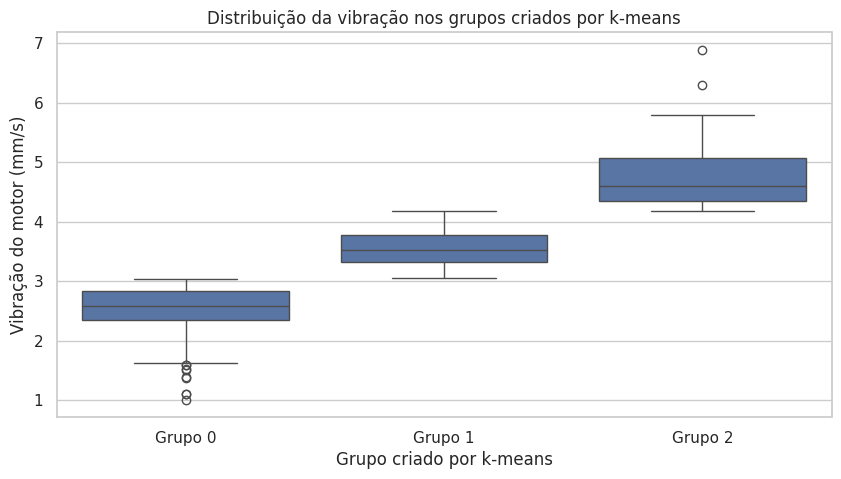

In [ ]:
# ------------------------------------------------------------
# 12) Comparação entre estratégias de discretização
# ------------------------------------------------------------

print("Cruzamento entre faixas de mesma largura e mesma frequência:")
display(pd.crosstab(
    dados_discretizacao["vibracao_faixa_largura"],
    dados_discretizacao["vibracao_faixa_frequencia"]
))

plt.figure(figsize=(10, 5))
sns.boxplot(
    data=dados_discretizacao,
    x="vibracao_faixa_kmeans_rotulo",
    y="vibracao_motor_mm_s"
)
plt.title("Distribuição da vibração nos grupos criados por k-means")
plt.xlabel("Grupo criado por k-means")
plt.ylabel("Vibração do motor (mm/s)")
plt.show()

### Interpretação da comparação

A tabela cruzada mostra que os métodos podem classificar o mesmo registro de maneiras diferentes.

O boxplot dos grupos de k-means ajuda a verificar se os grupos realmente separaram valores baixos, intermediários e altos de vibração.

Na prática, a escolha do método depende do objetivo:

- para limites simples e explicáveis, use mesma largura;
- para grupos com tamanhos equilibrados, use mesma frequência;
- para buscar grupos naturais nos dados, use k-means.

# Bloco 3 — Transformação numérico-numérico

Transformação numérico-numérica significa transformar uma variável numérica em outra variável numérica.

O objetivo mais comum é ajustar a escala dos atributos.

Isso é importante porque muitos modelos são sensíveis à escala, como:

- regressão linear com regularização;
- regressão logística;
- k-means;
- PCA;
- métodos baseados em distância.

Vamos comparar:

1. **Padronização** com `StandardScaler`;
2. **Normalização Min-Max** com `MinMaxScaler`;
3. **Escalonamento robusto** com `RobustScaler`.

## 14. Seleção de variáveis para escalonamento

Nesta célula, vamos escolher algumas variáveis numéricas com escalas diferentes.

Principais recursos:

- seleção de colunas por lista;
- `.describe()` para comparar média, mínimo, máximo e desvio padrão;
- `.copy()` para evitar alterar a base original.

In [ ]:
# ------------------------------------------------------------
# 13) Seleção de variáveis para transformação numérico-numérica
# ------------------------------------------------------------

variaveis_para_escalonar = [
    "temperatura_forno_c",
    "pressao_linha_bar",
    "vibracao_motor_mm_s",
    "consumo_energia_kwh",
    "tempo_ciclo_s",
    "qtd_produzida"
]

dados_numericos = dados[variaveis_para_escalonar].copy()

print("Resumo das variáveis antes do escalonamento:")
display(dados_numericos.describe().T.round(3))

Resumo das variáveis antes do escalonamento:


,count,mean,std,min,25%,50%,75%,max
temperatura_forno_c,750.0,180.236,5.325,165.154,176.455,180.228,183.934,196.059
pressao_linha_bar,750.0,6.005,0.466,4.500,5.722,6.010,6.316,7.388
vibracao_motor_mm_s,750.0,3.226,0.784,1.011,2.691,3.214,3.701,6.890
consumo_energia_kwh,750.0,94.529,3.944,82.886,91.929,94.481,97.128,109.292
tempo_ciclo_s,750.0,42.288,4.002,30.000,39.804,42.272,45.070,55.057
qtd_produzida,750.0,1186.803,89.456,870.075,1125.563,1186.199,1241.141,1449.733


### Interpretação

As variáveis estão em escalas diferentes.

Por exemplo, `pressao_linha_bar` está em torno de 6, enquanto `qtd_produzida` pode estar acima de 1000.

Se usarmos um modelo sensível à escala, variáveis com valores maiores podem dominar o cálculo, mesmo que não sejam necessariamente mais importantes.

## 15. Padronização com `StandardScaler`

A padronização transforma os dados para média próxima de 0 e desvio padrão próximo de 1.

O `StandardScaler` calcula:

- média da variável;
- desvio padrão da variável;
- valor transformado.

Principais recursos:

- `StandardScaler()`: cria o transformador.
- `.fit_transform(...)`: aprende os parâmetros e transforma os dados.
- `pd.DataFrame(...)`: transforma o resultado em tabela novamente.

A padronização é muito usada com regressão, regressão logística, Lasso, Ridge e PCA.

$$
x^{novo}_{ij}=\frac{x_{ij}-\mu_j}{\sigma_{j}}
$$


In [ ]:
# ------------------------------------------------------------
# 14) Padronização com StandardScaler
# ------------------------------------------------------------

scaler_standard = StandardScaler()

dados_standard_array = scaler_standard.fit_transform(dados_numericos)

dados_standard = pd.DataFrame(
    dados_standard_array,
    columns=[coluna + "_standard" for coluna in variaveis_para_escalonar],
    index=dados.index
)

print("Resumo após padronização:")
display(dados_standard.describe().T.round(3))

display(dados_standard.head())

Resumo após padronização:


,count,mean,std,min,25%,50%,75%,max
temperatura_forno_c_standard,750.0,-0.0,1.001,-2.834,-0.710,-0.001,0.695,2.973
pressao_linha_bar_standard,750.0,0.0,1.001,-3.229,-0.607,0.012,0.669,2.969
vibracao_motor_mm_s_standard,750.0,0.0,1.001,-2.829,-0.684,-0.016,0.606,4.679
consumo_energia_kwh_standard,750.0,0.0,1.001,-2.954,-0.660,-0.012,0.659,3.745
tempo_ciclo_s_standard,750.0,0.0,1.001,-3.073,-0.621,-0.004,0.696,3.193
qtd_produzida_standard,750.0,0.0,1.001,-3.543,-0.685,-0.007,0.608,2.941


,temperatura_forno_c_standard,pressao_linha_bar_standard,vibracao_motor_mm_s_standard,consumo_energia_kwh_standard,tempo_ciclo_s_standard,qtd_produzida_standard
0,0.565,-1.244,-1.764,-0.483,-1.378,-0.509
1,-0.952,0.104,-0.244,-1.322,0.207,-1.176
2,-0.804,0.402,-0.690,-0.550,-0.375,0.915
3,0.187,0.327,-1.405,-0.090,-1.097,0.400
4,2.973,-0.117,-0.138,0.471,-0.221,0.578


### Interpretação

Após a padronização, as médias ficam próximas de 0 e os desvios padrão próximos de 1.

Isso não significa que os dados ficaram “melhores” em todos os sentidos. Significa apenas que foram colocados em uma escala comparável para determinados modelos.

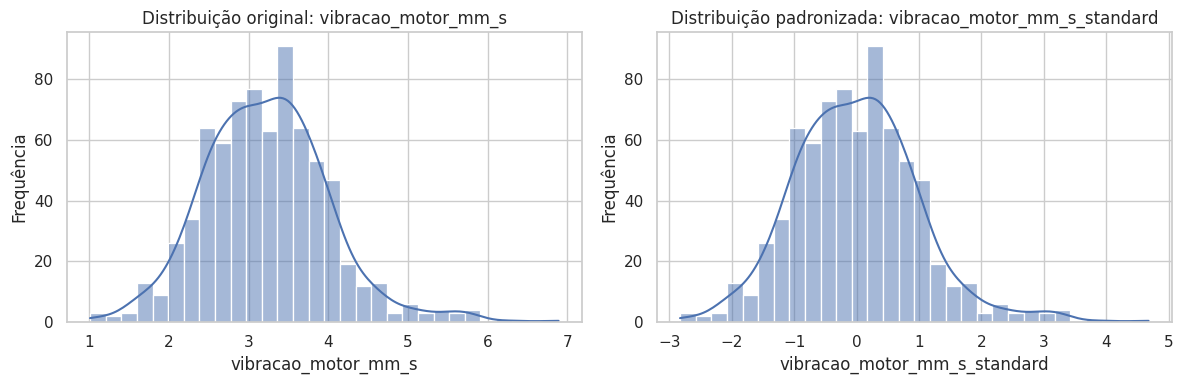

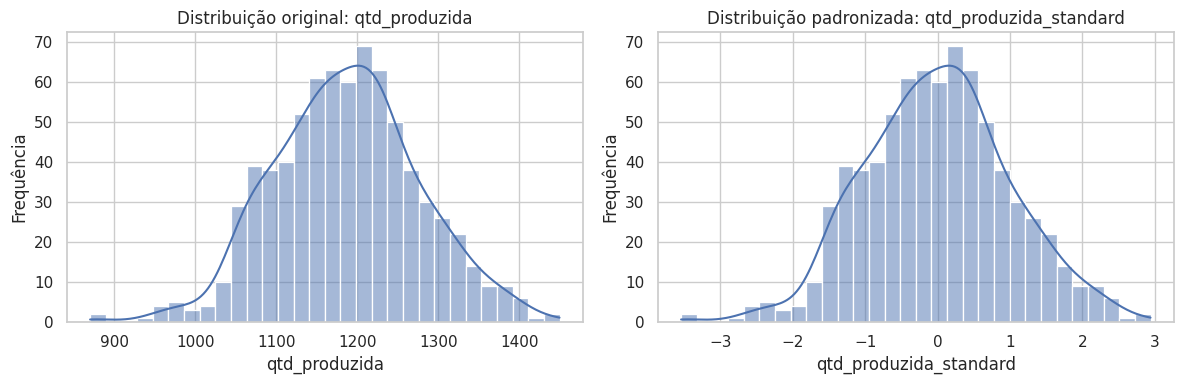

In [ ]:
# ------------------------------------------------------------
# 15) Histogramas: comparação antes e depois da padronização
# ------------------------------------------------------------

variaveis_comparar = [
    "vibracao_motor_mm_s",
    "qtd_produzida"
]

for variavel in variaveis_comparar:

    coluna_standard = variavel + "_standard"

    plt.figure(figsize=(12, 4))

    # Histograma da variável original
    plt.subplot(1, 2, 1)
    sns.histplot(
        dados[variavel],
        kde=True,
        bins=30
    )
    plt.title(f"Distribuição original: {variavel}")
    plt.xlabel(variavel)
    plt.ylabel("Frequência")

    # Histograma da variável padronizada
    plt.subplot(1, 2, 2)
    sns.histplot(
        dados_standard[coluna_standard],
        kde=True,
        bins=30
    )
    plt.title(f"Distribuição padronizada: {coluna_standard}")
    plt.xlabel(coluna_standard)
    plt.ylabel("Frequência")

    plt.tight_layout()
    plt.show()

## 16. Normalização Min-Max com `MinMaxScaler`

A normalização Min-Max transforma os valores para um intervalo definido, geralmente de 0 a 1.

Principais recursos:

- `MinMaxScaler()`: cria o transformador.
- `feature_range=(0, 1)`: intervalo padrão.
- `.fit_transform(...)`: aprende mínimo e máximo e transforma os dados.

Essa transformação é fácil de interpretar visualmente, pois todos os valores ficam entre 0 e 1.

$$
x^{novo}=min^{novo}+\frac{x - min(x)}{max(x) -min(x)}\ (max^{novo} - min^{novo})
$$

In [ ]:
# ------------------------------------------------------------
# 15) Normalização Min-Max
# ------------------------------------------------------------

scaler_minmax = MinMaxScaler(feature_range=(0, 1))

dados_minmax_array = scaler_minmax.fit_transform(dados_numericos)

dados_minmax = pd.DataFrame(
    dados_minmax_array,
    columns=[coluna + "_minmax" for coluna in variaveis_para_escalonar],
    index=dados.index
)

print("Resumo após Min-Max:")
display(dados_minmax.describe().T.round(3))

display(dados_minmax.head())

Resumo após Min-Max:


,count,mean,std,min,25%,50%,75%,max
temperatura_forno_c_minmax,750.0,0.488,0.172,0.0,0.366,0.488,0.608,1.0
pressao_linha_bar_minmax,750.0,0.521,0.161,0.0,0.423,0.523,0.629,1.0
vibracao_motor_mm_s_minmax,750.0,0.377,0.133,0.0,0.286,0.375,0.458,1.0
consumo_energia_kwh_minmax,750.0,0.441,0.149,0.0,0.342,0.439,0.539,1.0
tempo_ciclo_s_minmax,750.0,0.490,0.160,0.0,0.391,0.490,0.601,1.0
qtd_produzida_minmax,750.0,0.546,0.154,0.0,0.441,0.545,0.640,1.0


,temperatura_forno_c_minmax,pressao_linha_bar_minmax,vibracao_motor_mm_s_minmax,consumo_energia_kwh_minmax,tempo_ciclo_s_minmax,qtd_produzida_minmax
0,0.585,0.320,0.142,0.369,0.270,0.468
1,0.324,0.538,0.344,0.244,0.524,0.365
2,0.350,0.586,0.285,0.359,0.431,0.687
3,0.520,0.574,0.190,0.427,0.315,0.608
4,1.000,0.502,0.358,0.511,0.455,0.636


### Interpretação

Após o Min-Max, os valores ficam no intervalo de 0 a 1.

O menor valor observado vira 0 e o maior vira 1.

Atenção: se houver outliers, eles podem comprimir os demais valores em uma faixa pequena. Por isso, essa técnica pode ser sensível a valores extremos.

## 17. Escalonamento robusto com `RobustScaler`

O `RobustScaler` usa a mediana e o intervalo interquartil, também chamado de IQR.

Ele é menos sensível a outliers do que `StandardScaler` e `MinMaxScaler`.

Principais recursos:

- `RobustScaler()`: cria o transformador.
- `.fit_transform(...)`: aprende mediana e IQR e transforma os dados.

Essa técnica se conecta diretamente à aula anterior sobre IQR e outliers.

$$
x^{novo}=\frac{x - mediana}{IQR}=\frac{x - mediana}{Q_3-Q_1}\\
x^{novo}=\frac{x - mediana}{Q_{q_{max}}-Q_{q_{min}}}
$$

In [ ]:
# ------------------------------------------------------------
# 16) Escalonamento robusto
# ------------------------------------------------------------

scaler_robust = RobustScaler()

dados_robust_array = scaler_robust.fit_transform(dados_numericos)

dados_robust = pd.DataFrame(
    dados_robust_array,
    columns=[coluna + "_robust" for coluna in variaveis_para_escalonar],
    index=dados.index
)

print("Resumo após RobustScaler:")
display(dados_robust.describe().T.round(3))

display(dados_robust.head())

Resumo após RobustScaler:


,count,mean,std,min,25%,50%,75%,max
temperatura_forno_c_robust,750.0,0.001,0.712,-2.016,-0.505,0.0,0.495,2.117
pressao_linha_bar_robust,750.0,-0.009,0.784,-2.540,-0.484,0.0,0.516,2.318
vibracao_motor_mm_s_robust,750.0,0.012,0.776,-2.181,-0.518,0.0,0.482,3.640
consumo_energia_kwh_robust,750.0,0.009,0.759,-2.230,-0.491,0.0,0.509,2.849
tempo_ciclo_s_robust,750.0,0.003,0.760,-2.330,-0.469,0.0,0.531,2.428
qtd_produzida_robust,750.0,0.005,0.774,-2.735,-0.525,-0.0,0.475,2.280


,temperatura_forno_c_robust,pressao_linha_bar_robust,vibracao_motor_mm_s_robust,consumo_energia_kwh_robust,tempo_ciclo_s_robust,qtd_produzida_robust
0,0.403,-0.984,-1.355,-0.357,-1.044,-0.388
1,-0.677,0.072,-0.177,-0.993,0.161,-0.904
2,-0.571,0.306,-0.523,-0.408,-0.282,0.713
3,0.134,0.247,-1.077,-0.059,-0.830,0.315
4,2.117,-0.101,-0.095,0.366,-0.165,0.452


### Interpretação

O escalonamento robusto usa estatísticas menos afetadas por valores extremos.

Ele é útil quando a variável possui outliers, como pode acontecer com vibração, consumo de energia ou tempo de ciclo.

Não existe um único escalonador sempre melhor. A escolha depende do modelo e do comportamento dos dados.

## 18. Comparação visual dos escalonamentos

Vamos comparar a variável `qtd_produzida` antes e depois das transformações.

Principais recursos:

- `pd.DataFrame({...})`: monta uma tabela comparativa.
- `.melt(...)`: reorganiza a tabela para facilitar a criação de gráficos.
- `sns.boxplot(...)`: compara distribuições.

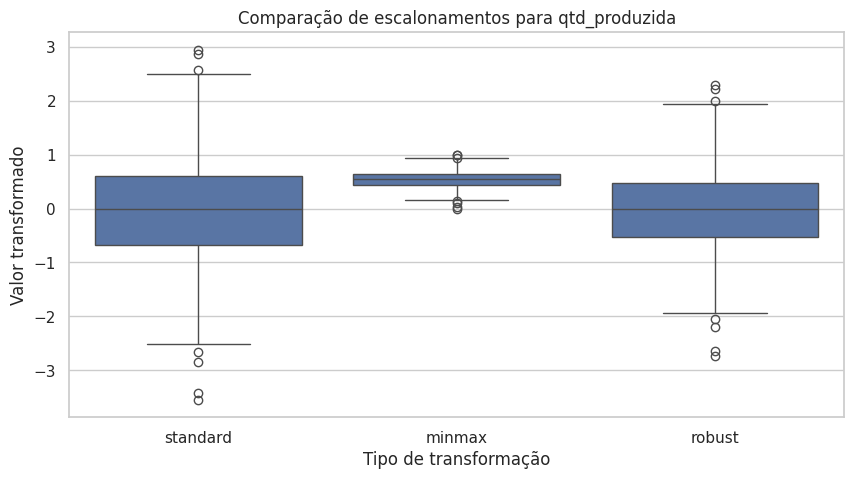

,standard,minmax,robust
0,-0.509,0.468,-0.388
1,-1.176,0.365,-0.904
2,0.915,0.687,0.713
3,0.400,0.608,0.315
4,0.578,0.636,0.452
5,-0.788,0.425,-0.604
6,0.399,0.608,0.314
7,-1.189,0.363,-0.915
8,-1.232,0.356,-0.948
9,0.358,0.602,0.282


In [ ]:
# ------------------------------------------------------------
# 17) Comparação visual dos escalonamentos
# ------------------------------------------------------------

comparacao_escala = pd.DataFrame({
   # "original": dados_numericos["qtd_produzida"],
    "standard": dados_standard["qtd_produzida_standard"],
    "minmax": dados_minmax["qtd_produzida_minmax"],
    "robust": dados_robust["qtd_produzida_robust"]
})

comparacao_escala_melt = comparacao_escala.melt(
    var_name="tipo_transformacao",
    value_name="valor"
)

plt.figure(figsize=(10, 5))
sns.boxplot(
    data=comparacao_escala_melt,
    x="tipo_transformacao",
    y="valor"
)
plt.title("Comparação de escalonamentos para qtd_produzida")
plt.xlabel("Tipo de transformação")
plt.ylabel("Valor transformado")
plt.show()

display(comparacao_escala.head(10))

### Interpretação da comparação

A transformação muda a escala, mas preserva a ordem dos registros.

Se uma observação tinha produção maior que outra antes da transformação, ela continuará maior depois da transformação.

O que muda é a unidade de comparação:

- original: unidade real do processo;
- standard: desvios em relação à média;
- minmax: posição entre mínimo e máximo;
- robust: posição em relação à mediana e ao IQR.

# Bloco 4 — Seleção de atributos

Seleção de atributos busca escolher variáveis mais úteis para o modelo.

Isso pode ajudar a:

- reduzir ruído;
- melhorar interpretação;
- diminuir redundância;
- simplificar modelos;
- reduzir custo computacional.

Vamos comparar três famílias:

1. **Filter**: usa critérios estatísticos.
2. **Wrapper**: usa um modelo para testar subconjuntos de atributos.
3. **Embedded**: seleciona atributos durante o treinamento do próprio modelo.

Nesta prática, vamos usar a variável `taxa_defeitos_pct` como alvo de regressão. Ao final, também mostramos como adaptar a ideia para classificação com `processo_critico`.

## 19. Preparação da matriz de atributos `X` e do alvo `y`

Antes da seleção de atributos, precisamos montar:

- `X`: matriz de atributos;
- `y`: variável-alvo.

Nesta célula, usaremos a base codificada criada anteriormente.

Também vamos aplicar padronização com `StandardScaler`, pois alguns métodos, como RFE com modelos lineares e Lasso, são sensíveis à escala.

Principais recursos:

- `.drop(...)`: remove colunas que não serão usadas como atributos.
- `.copy()`: cria uma cópia segura.
- `StandardScaler().fit_transform(...)`: padroniza os atributos.

In [ ]:
# ------------------------------------------------------------
# 18) Preparação de X e y para seleção de atributos
# ------------------------------------------------------------

# X contém apenas atributos numéricos já codificados.
# Removemos os alvos, pois eles não podem ser usados como entrada.
X = dados_codificados.drop(columns=["taxa_defeitos_pct", "processo_critico",
                                    "classe_qualidade"]).copy()

# y_reg é o alvo de regressão: taxa de defeitos
y_reg = dados_codificados["taxa_defeitos_pct"].copy()

# y_clf é o alvo de classificação: processo crítico ou não
y_clf = dados_codificados["processo_critico"].copy()

print("Dimensões de X:", X.shape)
print("Dimensões de y_reg:", y_reg.shape)
print("Dimensões de y_clf:", y_clf.shape)

# Padronização para métodos sensíveis à escala
scaler_selecao = StandardScaler()
X_scaled_array = scaler_selecao.fit_transform(X)

X_scaled = pd.DataFrame(
    X_scaled_array,
    columns=X.columns,
    index=X.index
)

display(X_scaled.head())

Dimensões de X: (750, 35)
Dimensões de y_reg: (750,)
Dimensões de y_clf: (750,)


,temperatura_forno_c,temperatura_forno_f,pressao_linha_bar,pressao_linha_backup,velocidade_esteira_m_min,vibracao_motor_mm_s,umidade_ambiente_pct,consumo_energia_kwh,consumo_energia_kwh_estimado,tempo_ciclo_s,tempo_setup_min,dias_desde_manutencao,qtd_produzida,sensor_ruido_aleatorio,codigo_turno_aleatorio,turno_Manhã,turno_Noite,turno_Tarde,maquina_M1,maquina_M2,maquina_M3,maquina_M4,tipo_produto_Peça A,tipo_produto_Peça B,tipo_produto_Peça C,tipo_produto_Peça D,linha_producao_Linha 1,linha_producao_Linha 2,linha_producao_Linha 3,nivel_manutencao_ord,nivel_desgaste_ord,criticidade_operacao_ord,fornecedor_lote_freq,codigo_produto_freq,codigo_operador_freq
0,0.565,0.565,-1.244,-1.160,0.014,-1.764,0.203,-0.483,-0.203,-1.378,0.425,1.022,-0.509,0.006,0.368,-0.778,1.593,-0.718,1.471,-0.640,-0.533,-0.456,-0.877,1.647,-0.506,-0.318,-0.877,1.307,-0.494,1.315,0.430,-0.818,-0.799,1.607,2.623
1,-0.952,-0.952,0.104,0.080,-1.081,-0.244,-0.585,-1.322,-0.889,0.207,-0.017,-1.405,-1.176,2.221,1.471,-0.778,-0.628,1.393,-0.680,1.562,-0.533,-0.456,-0.877,-0.607,-0.506,3.142,-0.877,1.307,-0.494,-1.195,-1.097,-0.818,-0.202,1.475,0.216
2,-0.804,-0.804,0.402,0.416,-1.032,-0.690,-2.021,-0.550,-1.084,-0.375,0.420,1.414,0.915,0.741,-0.219,-0.778,1.593,-0.718,1.471,-0.640,-0.533,-0.456,1.140,-0.607,-0.506,-0.318,1.140,-0.765,-0.494,1.315,0.430,0.542,0.660,-0.110,-0.185
3,0.187,0.187,0.327,0.394,-0.545,-1.405,0.110,-0.090,0.297,-1.097,0.726,-0.442,0.400,-0.897,-1.484,-0.778,-0.628,1.393,-0.680,1.562,-0.533,-0.456,-0.877,1.647,-0.506,-0.318,-0.877,1.307,-0.494,0.060,-1.097,-0.818,-0.533,-1.167,1.018
4,2.973,2.973,-0.117,-0.155,0.569,-0.138,-1.009,0.471,0.480,-0.221,-2.632,-0.691,0.578,0.069,-0.771,1.285,-0.628,-0.718,-0.680,-0.640,1.876,-0.456,-0.877,-0.607,1.975,-0.318,-0.877,-0.765,2.025,-1.195,-1.097,0.542,0.926,0.814,0.617


### Interpretação

A matriz `X` contém os atributos que serão avaliados pelos métodos de seleção.

Note que alguns atributos foram mantidos propositalmente mesmo sendo redundantes ou pouco informativos. Por exemplo:

- `temperatura_forno_c` e `temperatura_forno_f` são redundantes;
- `pressao_linha_bar` e `pressao_linha_backup` são quase duplicados;
- `sensor_ruido_aleatorio` deveria ter pouca relação com o alvo.

Isso torna a seleção de atributos mais didática.

## 20. Método Filter com `SelectKBest`

Métodos filter avaliam atributos usando critérios estatísticos, sem depender diretamente do modelo final.

Para regressão, podemos usar:

- `SelectKBest`: seleciona os melhores atributos segundo uma pontuação.
- `f_regression`: calcula uma pontuação estatística de associação com um alvo numérico.
- `k`: quantidade de atributos selecionados.

Principais recursos:

- `.fit(X, y)`: calcula as pontuações.
- `.scores_`: armazena as pontuações dos atributos.
- `.get_support()`: indica quais atributos foram selecionados.

##Estatística F e p-value

Para `f_regression`, a ideia matemática é testar, para cada atributo $X_j$, se ele tem relação linear com a variável-alvo $y$.

O teste considera a hipótese nula:

$$
H_0: \beta_j = 0
$$

ou seja:

> o atributo $X_j$ não tem relação linear significativa com $y$.

A **estatística F** mede a razão entre a variação explicada pelo modelo e a variação não explicada:

$$
F = \frac{\text{variação explicada por grau de liberdade}}{\text{variação residual por grau de liberdade}}
$$

pode ser escrita usando a correlação linear $r$ entre $X_j$ e $y$:

$$
F = \frac{r^2}{1-r^2}(n-2)
$$

Assim:

* se $r$ é próximo de 0, então $F$ tende a ser baixo;
* se $|r|$ é alto, então $F$ tende a ser alto.

Em `f_regression`, quanto **maior** a estatística F, maior tende a ser a evidência de que existe uma relação linear entre o atributo e o alvo.

Exemplo intuitivo:

```python
temperatura_forno → taxa_defeitos
```

Se mudanças na temperatura ajudam bastante a explicar mudanças na taxa de defeitos, a estatística F tende a ser alta.

---

**p-value**, ou valor-p, indica a probabilidade de observar uma relação tão forte quanto a encontrada **caso, na verdade, não exista relação real** entre o atributo e o alvo.

O **p-value** é definido como:

$$
p\text{-value} = P(F_{\text{teórico}} \geq F_{\text{observado}} \mid H_0)
$$

Ou seja:

> é a probabilidade de obter uma estatística F tão grande quanto a observada, supondo que a hipótese nula seja verdadeira.

Em outras palavras, ele mede quão improvável seria observar aquela relação linear se, na realidade, o atributo não tivesse relação com o alvo.

Em termos práticos:

| p-value                       | Interpretação                       |
| ----------------------------- | ----------------------------------- |
| pequeno, por exemplo `< 0.05` | há evidência de relação estatística |
| grande, por exemplo `> 0.05`  | não há evidência forte de relação   |

Portanto, em seleção de atributos:

* **F alto** → atributo parece relevante;
* **p-value baixo** → essa relevância parece estatisticamente confiável;
* **F baixo** e **p-value alto** → atributo provavelmente pouco útil para uma relação linear com o alvo.


In [ ]:
# ------------------------------------------------------------
# 19) Seleção de atributos pelo método Filter para regressão
# ------------------------------------------------------------

k = 12

seletor_filter_reg = SelectKBest(
    score_func=f_regression,
    k=k
)

seletor_filter_reg.fit(X_scaled, y_reg)

tabela_filter_reg = pd.DataFrame({
    "atributo": X_scaled.columns,
    "score_f_regression": seletor_filter_reg.scores_,
    "selecionado": seletor_filter_reg.get_support()
}).sort_values("score_f_regression", ascending=False)

print(f"Top {k} atributos selecionados pelo método Filter para regressão:")
display(tabela_filter_reg.head(k))

##Cria uma lista com os nomes dos atributos selecionados pelo método Filter.
atributos_filter_reg = list(tabela_filter_reg[tabela_filter_reg["selecionado"]]["atributo"])
print("Atributos selecionados:")
print(atributos_filter_reg)

Top 12 atributos selecionados pelo método Filter para regressão:


,atributo,score_f_regression,selecionado
31,criticidade_operacao_ord,227.034,True
5,vibracao_motor_mm_s,167.938,True
30,nivel_desgaste_ord,110.304,True
11,dias_desde_manutencao,78.303,True
29,nivel_manutencao_ord,72.239,True
6,umidade_ambiente_pct,14.102,True
10,tempo_setup_min,13.313,True
32,fornecedor_lote_freq,8.570,True
22,tipo_produto_Peça A,8.023,True
21,maquina_M4,7.995,True


Atributos selecionados:
['criticidade_operacao_ord', 'vibracao_motor_mm_s', 'nivel_desgaste_ord', 'dias_desde_manutencao', 'nivel_manutencao_ord', 'umidade_ambiente_pct', 'tempo_setup_min', 'fornecedor_lote_freq', 'tipo_produto_Peça A', 'maquina_M4', 'tipo_produto_Peça D', 'sensor_ruido_aleatorio']


#Explicando
```python
atributos_filter_reg = list(
    tabela_filter_reg[tabela_filter_reg["selecionado"]]["atributo"]
)
```

### 1. Esta parte cria uma máscara booleana

```python
tabela_filter_reg["selecionado"]
```

Ela retorna uma coluna com valores `True` ou `False`, indicando se cada atributo foi selecionado pelo `SelectKBest`.

Exemplo:

```python
atributo              selecionado
temperatura_forno     True
pressao_linha         False
vibracao_motor        True
```

### 2. Esta parte filtra apenas as linhas selecionadas

```python
tabela_filter_reg[tabela_filter_reg["selecionado"]]
```

Ela mantém apenas as linhas em que `"selecionado"` é `True`.

Resultado:

```python
atributo              selecionado
temperatura_forno     True
vibracao_motor        True
```

### 3. Esta parte pega apenas a coluna `"atributo"`

```python
tabela_filter_reg[tabela_filter_reg["selecionado"]]["atributo"]
```

Resultado:

```python
temperatura_forno
vibracao_motor
```

### 4. Esta parte converte para lista

```python
list(...)
```

Resultado final:

```python
atributos_filter_reg = [
    "temperatura_forno",
    "vibracao_motor"
]
```

Portanto, o código:

```python
atributos_filter_reg = list(tabela_filter_reg[tabela_filter_reg["selecionado"]]["atributo"])
```

significa:

> “pegue na tabela apenas os atributos marcados como selecionados e armazene seus nomes em uma lista.”


In [ ]:
# ------------------------------------------------------------
# 20) Nova base de entrada contendo apenas os atributos selecionados
# ------------------------------------------------------------

X_filter_reg = X_scaled[atributos_filter_reg].copy()

print("Dimensões da base de entrada original:")
print(X_scaled.shape)

print("Dimensões da nova base de entrada com atributos selecionados:")
print(X_filter_reg.shape)

print("Primeiras linhas da nova base de entrada para regressão:")
display(X_filter_reg.head())

Dimensões da base de entrada original:
(750, 35)
Dimensões da nova base de entrada com atributos selecionados:
(750, 12)
Primeiras linhas da nova base de entrada para regressão:


,criticidade_operacao_ord,vibracao_motor_mm_s,nivel_desgaste_ord,dias_desde_manutencao,nivel_manutencao_ord,umidade_ambiente_pct,tempo_setup_min,fornecedor_lote_freq,tipo_produto_Peça A,maquina_M4,tipo_produto_Peça D,sensor_ruido_aleatorio
0,-0.818,-1.764,0.430,1.022,1.315,0.203,0.425,-0.799,-0.877,-0.456,-0.318,0.006
1,-0.818,-0.244,-1.097,-1.405,-1.195,-0.585,-0.017,-0.202,-0.877,-0.456,3.142,2.221
2,0.542,-0.690,0.430,1.414,1.315,-2.021,0.420,0.660,1.140,-0.456,-0.318,0.741
3,-0.818,-1.405,-1.097,-0.442,0.060,0.110,0.726,-0.533,-0.877,-0.456,-0.318,-0.897
4,0.542,-0.138,-1.097,-0.691,-1.195,-1.009,-2.632,0.926,-0.877,-0.456,-0.318,0.069


### Interpretação do método Filter

O método filter seleciona atributos que possuem maior associação estatística com o alvo.

Ele é simples, rápido e útil como primeira análise.

Porém, ele avalia os atributos de forma mais individual. Portanto, pode não capturar bem interações entre variáveis ou redundâncias complexas.

## 21. Método Filter para classificação com `f_classif`

A mesma ideia pode ser aplicada a um alvo de classificação.

Agora o alvo é `processo_critico`, que indica se o processo está crítico ou não.

Usamos:

- `f_classif`: pontuação estatística adequada para classificação.
- `SelectKBest`: seleciona os melhores atributos.

##f_classif e Anova F-test

`f_classif` é uma função do `scikit-learn` usada para **seleção de atributos em problemas de classificação**.

Ela avalia, separadamente, cada atributo de entrada `X` em relação à classe-alvo `y`, usando um teste estatístico chamado **ANOVA F-test**.

**ANOVA F-test** é um teste estatístico usado para verificar se as **médias de um atributo numérico são diferentes entre grupos ou classes**.

No contexto de `f_classif`, ele responde à pergunta:

> “Este atributo tem valores médios diferentes para cada classe?”

Por exemplo, suponha um problema de classificação com três classes no atributo-alvo:

```python
status_maquina = ["normal", "atenção", "falha"]
```

E um atributo:

```python
vibracao_motor_mm_s
```

O ANOVA F-test verifica se a média da vibração é parecida ou diferente entre as classes:

```text
normal   → média baixa
atenção  → média intermediária
falha    → média alta
```

A estatística F compara:

$$
F = \frac{\text{variação entre os grupos}}{\text{variação dentro dos grupos}}
$$

Interpretação:

| Resultado         | Significado                                               |
| ----------------- | --------------------------------------------------------- |
| **F alto**        | as médias entre as classes são bem diferentes             |
| **F baixo**       | as médias entre as classes são parecidas                  |
| **p-value baixo** | há evidência de que o atributo ajuda a separar as classes |
| **p-value alto**  | não há evidência forte de diferença entre as classes      |


A documentação do scikit-learn descreve `f_classif` como uma função que calcula o **valor F da ANOVA** para a amostra fornecida e retorna uma estatística F e um p-value para cada atributo. ([Scikit-learn][1])

Exemplo de uso:

```python
from sklearn.feature_selection import SelectKBest, f_classif

seletor_filter_clf = SelectKBest(
    score_func=f_classif,
    k=12
)

seletor_filter_clf.fit(X_scaled, y_clf)
```

Nesse caso, o `SelectKBest` usa `f_classif` para medir quais atributos ajudam mais a **separar as classes** da variável-alvo.

Por exemplo, suponha agore que o alvo seja:

```python
status_falha = ["normal", "risco", "falha"]
```

E um atributo seja:

```python
vibracao_motor_mm_s
```

O `f_classif` verifica se os valores médios de `vibracao_motor_mm_s` são significativamente diferentes entre as classes `normal`, `risco` e `falha`.

A interpretação é:

| Resultado       | Interpretação                                          |
| --------------- | ------------------------------------------------------ |
| `F` alto        | o atributo separa bem as classes                       |
| `F` baixo       | o atributo separa pouco as classes                     |
| `p-value` baixo | há evidência estatística de diferença entre as classes |
| `p-value` alto  | não há evidência forte de diferença entre as classes   |

Portanto, em poucas palavras:

> `f_classif` mede se um atributo numérico tem valores significativamente diferentes entre as classes do problema.

Diferença importante:

```python
f_regression  → usado em regressão, quando y é numérico contínuo
f_classif     → usado em classificação, quando y representa classes
```

O guia do scikit-learn apresenta `f_classif` como uma função de seleção univariada para classificação, ao lado de `chi2` e `mutual_info_classif`. Também destaca que métodos baseados em F-test estimam dependência linear entre variáveis. ([Scikit-learn][2])

[1]: https://scikit-learn.org/stable/modules/generated/sklearn.feature_selection.f_classif.html "f_classif — scikit-learn 1.8.0 documentation"
[2]: https://scikit-learn.org/stable/modules/feature_selection.html "1.13. Feature selection — scikit-learn 1.8.0 documentation"


In [ ]:
# ------------------------------------------------------------
# 20) Seleção de atributos pelo método Filter para classificação
# ------------------------------------------------------------

seletor_filter_clf = SelectKBest(
    score_func=f_classif,
    k=k
)

seletor_filter_clf.fit(X_scaled, y_clf)

tabela_filter_clf = pd.DataFrame({
    "atributo": X_scaled.columns,
    "score_f_classif": seletor_filter_clf.scores_,
    "selecionado": seletor_filter_clf.get_support()
}).sort_values("score_f_classif", ascending=False)

print(f"Top {k} atributos selecionados pelo método Filter para classificação:")
display(tabela_filter_clf.head(k))

atributos_filter_clf = list(tabela_filter_clf[tabela_filter_clf["selecionado"]]["atributo"])
print("Atributos selecionados:")
print(atributos_filter_clf)

Top 12 atributos selecionados pelo método Filter para classificação:


,atributo,score_f_classif,selecionado
31,criticidade_operacao_ord,174.337,True
5,vibracao_motor_mm_s,95.539,True
30,nivel_desgaste_ord,74.059,True
29,nivel_manutencao_ord,47.068,True
11,dias_desde_manutencao,46.826,True
6,umidade_ambiente_pct,8.445,True
21,maquina_M4,8.058,True
25,tipo_produto_Peça D,6.476,True
22,tipo_produto_Peça A,6.293,True
10,tempo_setup_min,5.909,True


Atributos selecionados:
['criticidade_operacao_ord', 'vibracao_motor_mm_s', 'nivel_desgaste_ord', 'nivel_manutencao_ord', 'dias_desde_manutencao', 'umidade_ambiente_pct', 'maquina_M4', 'tipo_produto_Peça D', 'tipo_produto_Peça A', 'tempo_setup_min', 'fornecedor_lote_freq', 'sensor_ruido_aleatorio']


In [ ]:
# ------------------------------------------------------------
# 21) Nova base de entrada contendo apenas os atributos selecionados
# ------------------------------------------------------------

X_filter_clf = X_scaled[atributos_filter_clf].copy()

print("Dimensões da base de entrada original:")
print(X_scaled.shape)

print("Dimensões da nova base de entrada com atributos selecionados:")
print(X_filter_clf.shape)

print("Primeiras linhas da nova base de entrada:")
display(X_filter_clf.head())

Dimensões da base de entrada original:
(750, 35)
Dimensões da nova base de entrada com atributos selecionados:
(750, 12)
Primeiras linhas da nova base de entrada:


,criticidade_operacao_ord,vibracao_motor_mm_s,nivel_desgaste_ord,nivel_manutencao_ord,dias_desde_manutencao,umidade_ambiente_pct,maquina_M4,tipo_produto_Peça D,tipo_produto_Peça A,tempo_setup_min,fornecedor_lote_freq,sensor_ruido_aleatorio
0,-0.818,-1.764,0.430,1.315,1.022,0.203,-0.456,-0.318,-0.877,0.425,-0.799,0.006
1,-0.818,-0.244,-1.097,-1.195,-1.405,-0.585,-0.456,3.142,-0.877,-0.017,-0.202,2.221
2,0.542,-0.690,0.430,1.315,1.414,-2.021,-0.456,-0.318,1.140,0.420,0.660,0.741
3,-0.818,-1.405,-1.097,0.060,-0.442,0.110,-0.456,-0.318,-0.877,0.726,-0.533,-0.897
4,0.542,-0.138,-1.097,-1.195,-0.691,-1.009,-0.456,-0.318,-0.877,-2.632,0.926,0.069


### Interpretação

A mudança principal é a função de pontuação:

- `f_regression` para alvo numérico;
- `f_classif` para alvo categórico ou binário.

Essa distinção é importante porque regressão e classificação respondem perguntas diferentes.

## 22. Método Wrapper com RFE

RFE significa **Recursive Feature Elimination**, ou eliminação recursiva de atributos.

A ideia é:

1. treinar um modelo;
2. avaliar a importância dos atributos;
3. remover os menos importantes;
4. repetir até chegar ao número desejado de atributos.

Principais recursos:

- `RFE(...)`: cria o seletor wrapper.
- `estimator`: modelo usado para avaliar atributos.
- `n_features_to_select`: número de atributos a manter.
- `step`: quantos atributos remover a cada rodada.
- `.fit(X, y)`: executa o processo.
- `.support_`: indica atributos selecionados.
- `.ranking_`: mostra o ranking dos atributos.

Nesta célula, usaremos `LinearRegression` como modelo base para selecionar atributos para prever `taxa_defeitos_pct`.

In [ ]:
# ------------------------------------------------------------
# 21) Seleção de atributos pelo método Wrapper com RFE
# ------------------------------------------------------------

modelo_base_rfe = LinearRegression()

seletor_rfe = RFE(
    estimator=modelo_base_rfe,
    n_features_to_select=12,
    step=1
)

seletor_rfe.fit(X_scaled, y_reg)

tabela_rfe = pd.DataFrame({
    "atributo": X_scaled.columns,
    "selecionado": seletor_rfe.support_,#retorna um vetor booleano,
    #com valores True ou False, indicando atributos selecionados pelo RFE.
    "ranking": seletor_rfe.ranking_#Valores maiores que 1 indicam atributos
    #descartados. Quanto maior o valor, pior a posição do atributo na seleção.
}).sort_values(["ranking", "atributo"])

print("Atributos selecionados pelo RFE:")
display(tabela_rfe[tabela_rfe["selecionado"]])

print("\nRanking dos atributos:")
display(tabela_rfe.head(20))

atributos_rfe = list(tabela_rfe[tabela_rfe["selecionado"]]["atributo"])
print("Atributos selecionados:")
print(atributos_rfe)

Atributos selecionados pelo RFE:


,atributo,selecionado,ranking
7,consumo_energia_kwh,True,1
8,consumo_energia_kwh_estimado,True,1
31,criticidade_operacao_ord,True,1
11,dias_desde_manutencao,True,1
32,fornecedor_lote_freq,True,1
30,nivel_desgaste_ord,True,1
3,pressao_linha_backup,True,1
2,pressao_linha_bar,True,1
0,temperatura_forno_c,True,1
1,temperatura_forno_f,True,1



Ranking dos atributos:


,atributo,selecionado,ranking
7,consumo_energia_kwh,True,1
8,consumo_energia_kwh_estimado,True,1
31,criticidade_operacao_ord,True,1
11,dias_desde_manutencao,True,1
32,fornecedor_lote_freq,True,1
30,nivel_desgaste_ord,True,1
3,pressao_linha_backup,True,1
2,pressao_linha_bar,True,1
0,temperatura_forno_c,True,1
1,temperatura_forno_f,True,1


Atributos selecionados:
['consumo_energia_kwh', 'consumo_energia_kwh_estimado', 'criticidade_operacao_ord', 'dias_desde_manutencao', 'fornecedor_lote_freq', 'nivel_desgaste_ord', 'pressao_linha_backup', 'pressao_linha_bar', 'temperatura_forno_c', 'temperatura_forno_f', 'umidade_ambiente_pct', 'vibracao_motor_mm_s']


### Interpretação do RFE

O RFE é mais próximo do uso real de modelos porque seleciona atributos usando um estimador.

No exemplo, o estimador foi uma regressão linear.

O parâmetro `step=1` significa que o RFE remove um atributo por vez. Isso é didático, mas pode ser mais demorado em bases grandes.

Para bases maiores, poderia ser usado `step=2`, `step=5` ou uma fração como `step=0.1` (percentual de atributos removidos por iteração).

## 23. Método Embedded com Lasso


No método embedded, a seleção de atributos acontece durante o treinamento do próprio modelo.

A Lasso é um exemplo clássico: ela pode reduzir alguns coeficientes exatamente para zero.

A regressão Lasso tenta ajustar bem os dados, mas também penaliza coeficientes muito grandes. A ideia é minimizar algo como:

$$
\text{erro do modelo} + \alpha \sum |\beta_j|
$$

onde:

* $\beta_j$ são os coeficientes dos atributos;
* $\sum |\beta_j|$ é a penalização Lasso, também chamada de regularização $L_1$;
* $\alpha$ controla o peso dessa penalização.

Interpretação prática:

| Valor de `alpha`     | Efeito                                                                   |
| -------------------- | ------------------------------------------------------------------------ |
| `alpha` pequeno      | pouca regularização; o modelo se aproxima mais da regressão linear comum |
| `alpha` grande       | mais regularização; os coeficientes são mais reduzidos                   |
| `alpha` muito grande | vários coeficientes podem virar exatamente zero                          |

Esse último ponto é importante: o Lasso pode fazer **seleção automática de atributos**, porque atributos com coeficiente zero deixam de contribuir para o modelo.


Principais recursos:

- `LassoCV`: ajusta automaticamente a força da regularização usando validação cruzada.
- `cv=5`: usa 5 divisões internas para escolher o parâmetro.
  * O principal objetivo do cv=5 no LassoCV é ajudar a escolher automaticamente o melhor valor de alpha (penalização).
- `.coef_`: coeficientes aprendidos pelo modelo.
- coeficientes próximos de zero indicam atributos pouco usados pelo modelo.

Atenção: Lasso é sensível à escala. Por isso usamos `X_scaled`.




In [ ]:
# ------------------------------------------------------------
# 22) Seleção Embedded com Lasso
# ------------------------------------------------------------

modelo_lasso = LassoCV(
    cv=5,
    random_state=42,
    max_iter=20000
)

modelo_lasso.fit(X_scaled, y_reg)

tabela_lasso = pd.DataFrame({
    "atributo": X_scaled.columns,
    "coeficiente": modelo_lasso.coef_,
    "coef_abs": np.abs(modelo_lasso.coef_)
}).sort_values("coef_abs", ascending=False)

# Consideramos selecionados os atributos com coeficiente diferente de zero.
tabela_lasso["selecionado"] = tabela_lasso["coef_abs"] > 1e-6

print("Alpha escolhido pelo LassoCV:", modelo_lasso.alpha_)

print("\nAtributos com maior coeficiente absoluto:")
display(tabela_lasso.head(20))

atributos_lasso = list(tabela_lasso[tabela_lasso["selecionado"]]["atributo"])
print("Quantidade de atributos selecionados pela Lasso:", len(atributos_lasso))
print(atributos_lasso)

Alpha escolhido pelo LassoCV: 0.054913498157981626

Atributos com maior coeficiente absoluto:


,atributo,coeficiente,coef_abs,selecionado
31,criticidade_operacao_ord,0.521,0.521,True
5,vibracao_motor_mm_s,0.504,0.504,True
6,umidade_ambiente_pct,0.173,0.173,True
11,dias_desde_manutencao,0.139,0.139,True
29,nivel_manutencao_ord,0.077,0.077,True
32,fornecedor_lote_freq,0.066,0.066,True
13,sensor_ruido_aleatorio,-0.066,0.066,True
22,tipo_produto_Peça A,-0.057,0.057,True
25,tipo_produto_Peça D,0.052,0.052,True
26,linha_producao_Linha 1,-0.048,0.048,True


Quantidade de atributos selecionados pela Lasso: 14
['criticidade_operacao_ord', 'vibracao_motor_mm_s', 'umidade_ambiente_pct', 'dias_desde_manutencao', 'nivel_manutencao_ord', 'fornecedor_lote_freq', 'sensor_ruido_aleatorio', 'tipo_produto_Peça A', 'tipo_produto_Peça D', 'linha_producao_Linha 1', 'pressao_linha_backup', 'codigo_operador_freq', 'codigo_produto_freq', 'maquina_M3']


### Interpretação da Lasso

A Lasso combina treinamento do modelo e seleção de atributos.

Quando um coeficiente fica zero, significa que o modelo não usou aquele atributo.

Essa técnica é muito útil para introduzir a ideia de modelos regularizados, que será importante nas aulas sobre regressão Ridge e Lasso.

## 24. Método Embedded com importância de atributos em Random Forest

Modelos baseados em árvores também podem indicar importância de atributos.

Aqui usamos `RandomForestRegressor`.

Principais recursos:

- `RandomForestRegressor(...)`: cria uma floresta aleatória para regressão.
- `n_estimators`: número de árvores.
- `random_state`: garante reprodutibilidade.
- `.feature_importances_`: importância estimada de cada atributo.

Atenção: importância de atributos em árvores é útil, mas deve ser interpretada com cuidado, especialmente quando há atributos correlacionados.

In [ ]:
# ------------------------------------------------------------
# 23) Seleção Embedded com importância de atributos em Random Forest
# ------------------------------------------------------------

modelo_rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    max_depth=6
)

modelo_rf.fit(X, y_reg)

tabela_rf = pd.DataFrame({
    "atributo": X.columns,
    "importancia": modelo_rf.feature_importances_
}).sort_values("importancia", ascending=False)

print("Atributos mais importantes segundo Random Forest:")
display(tabela_rf.head(15))

atributos_rf_top12 = list(tabela_rf.head(12)["atributo"])
print("Top 12 atributos pela Random Forest:")
print(atributos_rf_top12)

Atributos mais importantes segundo Random Forest:


,atributo,importancia
31,criticidade_operacao_ord,0.305
5,vibracao_motor_mm_s,0.217
0,temperatura_forno_c,0.064
1,temperatura_forno_f,0.056
6,umidade_ambiente_pct,0.052
11,dias_desde_manutencao,0.031
13,sensor_ruido_aleatorio,0.025
10,tempo_setup_min,0.024
14,codigo_turno_aleatorio,0.024
33,codigo_produto_freq,0.021


Top 12 atributos pela Random Forest:
['criticidade_operacao_ord', 'vibracao_motor_mm_s', 'temperatura_forno_c', 'temperatura_forno_f', 'umidade_ambiente_pct', 'dias_desde_manutencao', 'sensor_ruido_aleatorio', 'tempo_setup_min', 'codigo_turno_aleatorio', 'codigo_produto_freq', 'fornecedor_lote_freq', 'tempo_ciclo_s']


### Interpretação da importância em árvores

A Random Forest tende a destacar atributos que ajudam a reduzir erro nas divisões das árvores.

É comum que variáveis realmente relacionadas à taxa de defeitos, como vibração, temperatura, pressão, manutenção ou criticidade, apareçam bem posicionadas.

Porém, se dois atributos são redundantes, como temperatura em Celsius e Fahrenheit, o modelo pode dividir a importância entre eles.

## 25. Comparando os métodos de seleção

Agora vamos comparar os atributos selecionados pelos principais métodos.

Principais recursos:

- `set(...)`: cria conjuntos de atributos.
- `sorted(...)`: ordena os nomes.
- `pd.DataFrame(...)`: organiza a comparação em tabela.

In [ ]:
# ------------------------------------------------------------
# 24) Comparação dos métodos de seleção
# ------------------------------------------------------------

todos_atributos_comparacao = sorted(set(
    atributos_filter_reg
    + atributos_rfe
    + atributos_lasso
    + atributos_rf_top12
))

comparacao_selecao = pd.DataFrame({
    "atributo": todos_atributos_comparacao
})

comparacao_selecao["filter_regression"] = comparacao_selecao["atributo"].isin(atributos_filter_reg\)
comparacao_selecao["rfe_wrapper"] = comparacao_selecao["atributo"].isin(atributos_rfe)
comparacao_selecao["lasso_embedded"] = comparacao_selecao["atributo"].isin(atributos_lasso)
comparacao_selecao["rf_embedded_top12"] = comparacao_selecao["atributo"].isin(atributos_rf_top12)

comparacao_selecao["qtd_metodos"] = comparacao_selecao[[
    "filter_regression",
    "rfe_wrapper",
    "lasso_embedded",
    "rf_embedded_top12"
]].sum(axis=1)

comparacao_selecao = comparacao_selecao.sort_values(
    ["qtd_metodos", "atributo"],
    ascending=[False, True]
)

display(comparacao_selecao)

SyntaxError: unexpected character after line continuation character (999356805.py, line 16)

### Interpretação da comparação

Atributos selecionados por vários métodos merecem atenção especial.

No entanto, os métodos não precisam concordar completamente. Cada um usa um critério diferente:

- Filter usa associação estatística;
- RFE usa um modelo e elimina atributos;
- Lasso seleciona durante o ajuste dos coeficientes;
- Random Forest estima importância por divisões em árvores.

Em aplicações reais, a seleção final deve combinar evidência estatística, desempenho do modelo e conhecimento do domínio.

## 26. Observação importante: evitar vazamento de dados

Em uma aplicação real de aprendizado de máquina, devemos evitar **data leakage**, ou vazamento de dados.

Isso significa que transformações como:

- encoding;
- escalonamento;
- imputação;
- seleção de atributos;

devem ser ajustadas apenas nos dados de treino e depois aplicadas aos dados de teste.

Neste notebook, aplicamos as técnicas na base inteira porque o objetivo é didático. Nas próximas aulas de modelagem, o fluxo correto será:

1. separar treino e teste;
2. ajustar transformações no treino;
3. aplicar transformações no teste;
4. treinar o modelo;
5. avaliar no teste.

## 27. Atividade prática guiada

Agora é sua vez de experimentar.

Crie uma cópia da base com `.copy()` e teste pequenas modificações:

1. Use `pd.cut()` para criar faixas de `taxa_defeitos_pct`.
2. Use `pd.qcut()` para criar quatro grupos de `consumo_energia_kwh`.
3. Troque `n_bins=3` por `n_bins=4` no `KBinsDiscretizer`.
4. Troque `k=12` por `k=8` no `SelectKBest`.
5. Troque `n_features_to_select=12` por `n_features_to_select=8` no RFE.
6. Compare quais atributos continuam sendo selecionados.

O objetivo não é encontrar uma única resposta correta, mas entender como as escolhas de transformação e seleção alteram a preparação dos dados.

In [ ]:
# ------------------------------------------------------------
# 25) Espaço para experimentação dos alunos
# ------------------------------------------------------------

dados_experimento = dados.copy()

# Exemplo 1: criar faixas de taxa de defeitos com mesma largura
dados_experimento["defeitos_faixa_largura"] = pd.cut(
    dados_experimento["taxa_defeitos_pct"],
    bins=3,
    labels=["Baixa", "Média", "Alta"],
    include_lowest=True
)

# Exemplo 2: criar grupos de consumo de energia com mesma frequência
dados_experimento["energia_quartil"] = pd.qcut(
    dados_experimento["consumo_energia_kwh"],
    q=4,
    labels=["Q1", "Q2", "Q3", "Q4"],
    duplicates="drop"
)

print("Exemplo de novas colunas criadas:")
display(dados_experimento[[
    "taxa_defeitos_pct",
    "defeitos_faixa_largura",
    "consumo_energia_kwh",
    "energia_quartil"
]].head(15))

print("\nContagem por faixa de defeitos:")
display(dados_experimento["defeitos_faixa_largura"].value_counts().sort_index().to_frame("contagem"))

print("\nContagem por quartil de energia:")
display(dados_experimento["energia_quartil"].value_counts().sort_index().to_frame("contagem"))

### Interpretação da atividade

O uso de `.copy()` permite testar transformações sem alterar a base original.

Esse hábito é importante em ciência de dados, porque muitas transformações são experimentais. Antes de decidir qual técnica usar em um pipeline final, normalmente comparamos várias alternativas.

## 28. Conclusão

Nesta aula prática, usamos o mesmo problema industrial da Aula Prática 02 para avançar no pipeline de aprendizado de máquina.

Aprendemos a:

- transformar categorias nominais com One-Hot Encoding;
- transformar categorias ordinais com mapeamento;
- codificar categorias de alta cardinalidade com Frequency Encoding;
- discretizar variáveis numéricas usando `pd.cut`, `pd.qcut` e k-means;
- aplicar padronização, Min-Max e escalonamento robusto;
- selecionar atributos com métodos filter, wrapper e embedded;
- comparar resultados de diferentes métodos de seleção.

A principal mensagem é:

> transformar e selecionar atributos não é apenas uma etapa técnica; é uma etapa que conecta conhecimento do problema, estatística, programação e modelagem.

Nas próximas aulas, essa base preparada poderá ser usada para treinar modelos de regressão, classificação, árvores de decisão e ensembles.